# Strategy Beta — Early Spatial Fusion
**SOAI Labs 2026 · Language-Guided Robotics**

Research question: Does baking bounding box spatial information directly into the CNN input prevent feature laziness and improve performance over the ResNet18 baseline?

**Key idea:** Instead of appending a detection vector the agent can ignore, we stack a spatial instance mask onto the RGB frame BEFORE the CNN. The network must learn visual and spatial features simultaneously.

```
RGB frame (H,W,3) + Instance mask (H,W,1) → ResNet18 (4-channel) → (512,)
```

Output shape stays (512,) — RL wrapper requires zero changes vs Alpha.

In [1]:
# Cell 1 — Install dependencies
!pip install pybullet stable-baselines3 gymnasium torch torchvision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 23.1 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 12.4 MB/s eta 0:00:00


In [2]:
# Cell 2 — Setup working directory structure
import sys, os

for folder in [
    '/kaggle/working/robotics/env/src',
    '/kaggle/working/rl',
    '/kaggle/working/nlp',
]:
    os.makedirs(folder, exist_ok=True)
    open(folder + '/__init__.py', 'w').close()

for folder in ['/kaggle/working/robotics', '/kaggle/working/robotics/env']:
    open(folder + '/__init__.py', 'w').close()

sys.path.insert(0, '/kaggle/working')
print("Directory structure ready")

Directory structure ready


In [3]:
# Cell 3 — Write config.py (Updated: 2-phase curriculum for 600k Kaggle limit)
config_code = '''
from enum import Enum
import pybullet as p
import numpy as np

class GraphicalMode(Enum):
    GUI = p.GUI
    DIRECT = p.DIRECT

class RenderMode(Enum):
    HUMAN = "human"
    RGB_ARRAY = "rgb_array"

NUM_JOINTS = 7
END_EFFECTOR_LINK_INDEX = 6
MAX_FORCE = 300.0
SIM_TIMESTEP = 1.0 / 240.0
SIM_STEPS_PER_ACTION = 4
MAX_EPISODE_STEPS = 500

JOINT_LOWER_LIMITS = np.array([-2.9671, -2.0944, -2.9671, -2.0944, -2.9671, -2.0944, -3.0543], dtype=np.float32)
JOINT_UPPER_LIMITS = np.array([2.9671,  2.0944,  2.9671,  2.0944,  2.9671,  2.0944,  3.0543], dtype=np.float32)
HOME_POSITION = np.zeros(7, dtype=np.float32)
MAX_JOINT_VELOCITY = 10.0

WORKSPACE_LOW  = np.array([-1.5, -1.5, 0.0], dtype=np.float32)
WORKSPACE_HIGH = np.array([1.5,  1.5,  1.5], dtype=np.float32)

# Camera parameters
CAM_DISTANCE = 1.5
CAM_YAW = 50
CAM_PITCH = -35
CAM_TARGET = [0, 0, 0.5]
RENDER_FPS = 30
RENDER_WIDTH = 224
RENDER_HEIGHT = 224

# Object parameters
NUM_OBJECTS = 4
OBJECT_COLORS = {
    "red":    [1.0, 0.0, 0.0, 1.0],
    "green":  [0.0, 1.0, 0.0, 1.0],
    "blue":   [0.0, 0.0, 1.0, 1.0],
    "yellow": [1.0, 1.0, 0.0, 1.0],
}
OBJECT_SHAPES   = ["box", "sphere", "cylinder"]
OBJECT_SIZE_MIN = 0.02
OBJECT_SIZE_MAX = 0.05

# Table parameters
TABLE_POSITION      = [0.5, 0.0, 0.2]
TABLE_HALF_EXTENTS  = [0.4, 0.4, 0.05]
TABLE_SURFACE_Z     = 0.42
SPAWN_RANGE         = 0.22

# GRIPPER PARAMETERS (Production-Grade: Safety Layer + Collision Detection)
GRIPPER_ATTACH_DISTANCE = 0.15   # Distance to trigger grasp (15cm)
GRIPPER_RELEASE_DISTANCE = 0.20  # Distance to trigger release (20cm)
MAX_GRASP_FORCE = 1000.0         # Constraint force for grasping

# SAFETY LAYER: Collision detection
GRIPPER_COLLISION_ZONE = 0.12    # Zone around gripper to check for interfering objects (12cm)
GRIPPER_MIN_ISOLATION = 0.10     # Minimum distance target must be from other objects (10cm)
MAX_GRASP_FAILURES = 3           # Fail after 3 consecutive grasp attempts

# Action space: first 7 dims = joint angles, 8th = gripper command [-1=open, +1=close]
ACTION_SPACE_DIM = 8

# Task instruction types (for reward shaping)
TASK_REACH = "reach"    # move, navigate, go, approach, head
TASK_PICK = "pick"      # pick, grab, get, take
TASK_PUSH = "push"      # push
TASK_PULL = "pull"      # pull, drag, draw
TASK_LIFT = "lift"      # lift, raise, hoist
TASK_PLACE = "place"    # place, set, put, drop
TASK_LOWER = "lower"    # lower, descend, bring down

# CURRICULUM PHASES (Optimized for 600k Kaggle limit)
# 2 phases: Phase 1 foundation, Phase 2 manipulation intro
CURRICULUM_PHASES = [
    (0,      300_000, {"reach": 0.80, "pick": 0.20, "push": 0.0, "pull": 0.0, "lift": 0.0, "place": 0.0, "lower": 0.0}),
    (300_000, 600_000, {"reach": 0.60, "pick": 0.30, "push": 0.05, "pull": 0.03, "lift": 0.01, "place": 0.01, "lower": 0.0}),
]
'''

with open('/kaggle/working/robotics/env/src/config.py', 'w') as f:
    f.write(config_code)
print("config.py written — 2-phase curriculum for 600k Kaggle limit")

config.py written — 2-phase curriculum for 600k Kaggle limit


In [4]:
# Cell 4 — Write environment.py (Updated: Production-grade gripper + collision detection + safety layer)
env_str = '''
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pybullet as p
import pybullet_data

from env.src.config import (
    GraphicalMode, NUM_JOINTS, END_EFFECTOR_LINK_INDEX, MAX_FORCE,
    SIM_TIMESTEP, SIM_STEPS_PER_ACTION, MAX_EPISODE_STEPS,
    JOINT_LOWER_LIMITS, JOINT_UPPER_LIMITS, HOME_POSITION,
    MAX_JOINT_VELOCITY, WORKSPACE_LOW, WORKSPACE_HIGH,
    CAM_DISTANCE, CAM_YAW, CAM_PITCH, CAM_TARGET,
    RENDER_WIDTH, RENDER_HEIGHT, RENDER_FPS, RenderMode,
    NUM_OBJECTS, OBJECT_COLORS, OBJECT_SIZE_MIN, OBJECT_SIZE_MAX,
    TABLE_POSITION, TABLE_HALF_EXTENTS, TABLE_SURFACE_Z, SPAWN_RANGE, OBJECT_SHAPES,
    GRIPPER_ATTACH_DISTANCE, GRIPPER_RELEASE_DISTANCE, MAX_GRASP_FORCE,
    GRIPPER_COLLISION_ZONE, GRIPPER_MIN_ISOLATION, MAX_GRASP_FAILURES, ACTION_SPACE_DIM
)


class KukaEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": RENDER_FPS}

    def __init__(self, render_mode=RenderMode.RGB_ARRAY.value):
        super().__init__()
        self.render_mode = render_mode
        # Action space: 8 dimensions (7 joints + 1 gripper)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(ACTION_SPACE_DIM,), dtype=np.float32)
        
        obs_low  = np.concatenate([JOINT_LOWER_LIMITS, np.full(NUM_JOINTS, -MAX_JOINT_VELOCITY, dtype=np.float32), WORKSPACE_LOW,  np.full(4, -1.0, dtype=np.float32)])
        obs_high = np.concatenate([JOINT_UPPER_LIMITS, np.full(NUM_JOINTS,  MAX_JOINT_VELOCITY, dtype=np.float32), WORKSPACE_HIGH, np.full(4,  1.0, dtype=np.float32)])
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, shape=(21,), dtype=np.float32)
        
        self._physics_client_id = -1
        self._kuka_id = None
        self._plane_id = None
        self._step_count = 0
        self._object_ids    = []
        self._object_colors = []
        self._object_shapes = []
        
        # GRIPPER STATE
        self._grasped_object_id = None
        self._grasp_constraint = None
        self._target_object_id = None      # Instruction-locked target
        self._grasp_failure_count = 0      # Track consecutive failures
        self._gripper_state = 0.0          # -1=open, 0=neutral, +1=close

    def set_target_object(self, obj_id):
        """Set target object for this episode (locked until reset)."""
        self._target_object_id = obj_id

    def _load_table(self):
        col = p.createCollisionShape(p.GEOM_BOX, halfExtents=TABLE_HALF_EXTENTS, physicsClientId=self._physics_client_id)
        vis = p.createVisualShape(p.GEOM_BOX,  halfExtents=TABLE_HALF_EXTENTS, rgbaColor=[0.6, 0.4, 0.2, 1.0], physicsClientId=self._physics_client_id)
        p.createMultiBody(baseMass=0, baseCollisionShapeIndex=col, baseVisualShapeIndex=vis, basePosition=TABLE_POSITION, physicsClientId=self._physics_client_id)

    def _load_objects(self):
        self._object_ids, self._object_colors, self._object_shapes = [], [], []
        self._grasped_object_id = None
        self._grasp_constraint = None
        self._grasp_failure_count = 0
        
        color_names = list(OBJECT_COLORS.keys())
        table_cx, table_cy = TABLE_POSITION[0], TABLE_POSITION[1]
        placed = []
        for i in range(NUM_OBJECTS):
            size       = float(self.np_random.uniform(OBJECT_SIZE_MIN, OBJECT_SIZE_MAX))
            color_name = color_names[i % len(color_names)]
            rgba       = OBJECT_COLORS[color_name]
            shape_name = OBJECT_SHAPES[int(self.np_random.integers(0, len(OBJECT_SHAPES)))]
            if shape_name == "box":
                col = p.createCollisionShape(p.GEOM_BOX,      halfExtents=[size, size, size],  physicsClientId=self._physics_client_id)
                vis = p.createVisualShape(p.GEOM_BOX,         halfExtents=[size, size, size],  rgbaColor=rgba, physicsClientId=self._physics_client_id)
            elif shape_name == "sphere":
                col = p.createCollisionShape(p.GEOM_SPHERE,   radius=size,                     physicsClientId=self._physics_client_id)
                vis = p.createVisualShape(p.GEOM_SPHERE,      radius=size,                     rgbaColor=rgba, physicsClientId=self._physics_client_id)
            else:
                col = p.createCollisionShape(p.GEOM_CYLINDER, radius=size, height=size*2,      physicsClientId=self._physics_client_id)
                vis = p.createVisualShape(p.GEOM_CYLINDER,    radius=size, length=size*2,      rgbaColor=rgba, physicsClientId=self._physics_client_id)
            for _ in range(50):
                ox, oy = float(self.np_random.uniform(-SPAWN_RANGE, SPAWN_RANGE)), float(self.np_random.uniform(-SPAWN_RANGE, SPAWN_RANGE))
                candidate = [table_cx + ox, table_cy + oy]
                if not any(np.sqrt((candidate[0]-p_[0])**2+(candidate[1]-p_[1])**2) < 0.10 for p_ in placed):
                    break
            pos = [candidate[0], candidate[1], TABLE_SURFACE_Z]
            placed.append(candidate)
            obj_id = p.createMultiBody(baseMass=0.1, baseCollisionShapeIndex=col, baseVisualShapeIndex=vis, basePosition=pos, physicsClientId=self._physics_client_id)
            self._object_ids.append(obj_id)
            self._object_colors.append(color_name)
            self._object_shapes.append(shape_name)

    def _get_object_state(self):
        state = {}
        for obj_id, color, shape in zip(self._object_ids, self._object_colors, self._object_shapes):
            pos, _ = p.getBasePositionAndOrientation(obj_id, physicsClientId=self._physics_client_id)
            state[obj_id] = {"pos": list(pos), "color": color, "shape": shape}
        return state

    def _check_collision_zone(self, ee_pos):
        """Check if any NON-TARGET objects are in gripper collision zone."""
        for obj_id in self._object_ids:
            if obj_id == self._target_object_id:
                continue  # Skip target object
            
            obj_pos, _ = p.getBasePositionAndOrientation(obj_id, physicsClientId=self._physics_client_id)
            dist = np.linalg.norm(ee_pos - np.array(obj_pos))
            
            if dist < GRIPPER_COLLISION_ZONE:
                return False  # Collision detected — unsafe to grasp
        
        return True  # Safe — no interfering objects

    def _check_target_isolation(self):
        """Check if target object is sufficiently isolated from other objects."""
        if self._target_object_id is None or self._target_object_id not in self._object_ids:
            return False
        
        target_pos, _ = p.getBasePositionAndOrientation(self._target_object_id, physicsClientId=self._physics_client_id)
        
        for obj_id in self._object_ids:
            if obj_id == self._target_object_id:
                continue
            
            obj_pos, _ = p.getBasePositionAndOrientation(obj_id, physicsClientId=self._physics_client_id)
            dist = np.linalg.norm(np.array(target_pos) - np.array(obj_pos))
            
            if dist < GRIPPER_MIN_ISOLATION:
                return False  # Target too close to other objects
        
        return True  # Target is isolated

    def _try_grasp(self):
        """Multi-stage safety check before grasping."""
        # Stage 1: Already grasping?
        if self._grasped_object_id is not None:
            return
        
        # Stage 2: Valid target set?
        if self._target_object_id is None or self._target_object_id not in self._object_ids:
            self._grasp_failure_count += 1
            return
        
        # Stage 3: Get EE position
        ee_state = p.getLinkState(self._kuka_id, END_EFFECTOR_LINK_INDEX, physicsClientId=self._physics_client_id)
        ee_pos = np.array(ee_state[0])
        
        # Stage 4: Check collision zone (no other objects near gripper)
        if not self._check_collision_zone(ee_pos):
            self._grasp_failure_count += 1
            return  # Unsafe — other objects in zone
        
        # Stage 5: Check target isolation
        if not self._check_target_isolation():
            self._grasp_failure_count += 1
            return  # Unsafe — target too close to others
        
        # Stage 6: Check distance to target
        obj_pos, _ = p.getBasePositionAndOrientation(self._target_object_id, physicsClientId=self._physics_client_id)
        distance = np.linalg.norm(ee_pos - np.array(obj_pos))
        
        if distance >= GRIPPER_ATTACH_DISTANCE:
            self._grasp_failure_count += 1
            return  # Too far
        
        # Stage 7: All checks passed — CREATE CONSTRAINT
        try:
            self._grasp_constraint = p.createConstraint(
                parentBodyUniqueId=self._kuka_id,
                parentLinkIndex=END_EFFECTOR_LINK_INDEX,
                childBodyUniqueId=self._target_object_id,
                childLinkIndex=-1,
                jointType=p.JOINT_FIXED,
                jointAxis=[0, 0, 0],
                parentFramePosition=[0, 0, 0],
                childFramePosition=[0, 0, 0],
                physicsClientId=self._physics_client_id
            )
            self._grasped_object_id = self._target_object_id
            self._grasp_failure_count = 0  # Reset on success
        except Exception as e:
            self._grasp_failure_count += 1

    def _release_grasp(self):
        """Release grasped object."""
        if self._grasp_constraint is not None:
            try:
                p.removeConstraint(self._grasp_constraint, physicsClientId=self._physics_client_id)
            except:
                pass
            self._grasp_constraint = None
        self._grasped_object_id = None
        self._grasp_failure_count = 0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if self._physics_client_id < 0:
            self._physics_client_id = p.connect(GraphicalMode.DIRECT.value)
            p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.resetSimulation(physicsClientId=self._physics_client_id)
        p.setGravity(0, 0, -10, physicsClientId=self._physics_client_id)
        p.setTimeStep(SIM_TIMESTEP, physicsClientId=self._physics_client_id)
        p.loadURDF("plane.urdf", physicsClientId=self._physics_client_id)
        self._kuka_id = p.loadURDF("kuka_iiwa/model.urdf", basePosition=[0,0,0], useFixedBase=True, physicsClientId=self._physics_client_id)
        for i in range(NUM_JOINTS):
            p.resetJointState(self._kuka_id, i, HOME_POSITION[i], physicsClientId=self._physics_client_id)
        
        self._load_table()
        self._load_objects()
        self._grasped_object_id = None
        self._grasp_constraint = None
        self._target_object_id = None  # Will be set by wrapper
        self._grasp_failure_count = 0
        self._gripper_state = 0.0
        self._step_count = 0
        
        for _ in range(SIM_STEPS_PER_ACTION):
            p.stepSimulation(physicsClientId=self._physics_client_id)
        
        obs  = self._get_observation()
        info = {
            "step_count": 0,
            "ee_position": obs[14:17].tolist(),
            "object_state": self._get_object_state(),
            "grasped_object_id": self._grasped_object_id,
            "grasp_failure_count": self._grasp_failure_count
        }
        return obs, info

    def step(self, action):
        action = np.clip(action, -1.0, 1.0)
        
        # First 7 dims: joint control
        joint_action = action[:7]
        midpoint = (JOINT_UPPER_LIMITS + JOINT_LOWER_LIMITS) / 2.0
        half_rng = (JOINT_UPPER_LIMITS - JOINT_LOWER_LIMITS) / 2.0
        joint_action_scaled = midpoint + joint_action * half_rng
        
        for i in range(NUM_JOINTS):
            p.setJointMotorControl2(bodyUniqueId=self._kuka_id, jointIndex=i, controlMode=p.POSITION_CONTROL, 
                                   targetPosition=float(joint_action_scaled[i]), force=MAX_FORCE, 
                                   physicsClientId=self._physics_client_id)
        
        # 8th dim: gripper command with safety checks
        gripper_cmd = float(action[7])
        self._gripper_state = gripper_cmd
        
        # Only attempt grasp if max failures not exceeded
        if gripper_cmd > 0.5 and self._grasp_failure_count < MAX_GRASP_FAILURES:
            self._try_grasp()
        elif gripper_cmd < -0.5:
            self._release_grasp()
        
        for _ in range(SIM_STEPS_PER_ACTION):
            p.stepSimulation(physicsClientId=self._physics_client_id)
        
        self._step_count += 1
        obs  = self._get_observation()
        info = {
            "step_count": self._step_count,
            "ee_position": obs[14:17].tolist(),
            "object_state": self._get_object_state(),
            "grasped_object_id": self._grasped_object_id,
            "grasp_failure_count": self._grasp_failure_count,
            "gripper_max_failures_exceeded": self._grasp_failure_count >= MAX_GRASP_FAILURES
        }
        return obs, 0.0, False, self._step_count >= MAX_EPISODE_STEPS, info

    def render(self):
        if self.render_mode == "rgb_array":
            return self._get_camera_image()
        return None

    def get_segmentation(self):
        """Returns (H, W) segmentation map — object IDs per pixel."""
        vm = p.computeViewMatrixFromYawPitchRoll(cameraTargetPosition=CAM_TARGET, distance=CAM_DISTANCE, yaw=CAM_YAW, pitch=CAM_PITCH, roll=0, upAxisIndex=2, physicsClientId=self._physics_client_id)
        pm = p.computeProjectionMatrixFOV(fov=60, aspect=RENDER_WIDTH/RENDER_HEIGHT, nearVal=0.1, farVal=100, physicsClientId=self._physics_client_id)
        _, _, rgb, _, seg = p.getCameraImage(RENDER_WIDTH, RENDER_HEIGHT, vm, pm, renderer=p.ER_TINY_RENDERER, physicsClientId=self._physics_client_id)
        frame = np.array(rgb, dtype=np.uint8).reshape(RENDER_HEIGHT, RENDER_WIDTH, 4)[:, :, :3]
        seg   = np.array(seg, dtype=np.int32).reshape(RENDER_HEIGHT, RENDER_WIDTH)
        return frame, seg

    def close(self):
        if self._physics_client_id >= 0:
            p.disconnect(physicsClientId=self._physics_client_id)
            self._physics_client_id = -1

    def _get_observation(self):
        jpos = np.zeros(NUM_JOINTS, dtype=np.float32)
        jvel = np.zeros(NUM_JOINTS, dtype=np.float32)
        for i in range(NUM_JOINTS):
            s = p.getJointState(self._kuka_id, i, physicsClientId=self._physics_client_id)
            jpos[i], jvel[i] = s[0], s[1]
        ee = p.getLinkState(self._kuka_id, END_EFFECTOR_LINK_INDEX, physicsClientId=self._physics_client_id)
        return np.clip(np.concatenate([jpos, jvel, np.array(ee[0], dtype=np.float32), np.array(ee[1], dtype=np.float32)]), 
                       self.observation_space.low, self.observation_space.high)

    def _get_camera_image(self):
        vm = p.computeViewMatrixFromYawPitchRoll(cameraTargetPosition=CAM_TARGET, distance=CAM_DISTANCE, yaw=CAM_YAW, pitch=CAM_PITCH, roll=0, upAxisIndex=2, physicsClientId=self._physics_client_id)
        pm = p.computeProjectionMatrixFOV(fov=60, aspect=RENDER_WIDTH/RENDER_HEIGHT, nearVal=0.1, farVal=100, physicsClientId=self._physics_client_id)
        _, _, rgb, _, _ = p.getCameraImage(RENDER_WIDTH, RENDER_HEIGHT, vm, pm, renderer=p.ER_TINY_RENDERER, physicsClientId=self._physics_client_id)
        return np.array(rgb, dtype=np.uint8).reshape(RENDER_HEIGHT, RENDER_WIDTH, 4)[:, :, :3]
'''

with open('/kaggle/working/robotics/env/src/environment.py', 'w') as f:
    f.write(env_str)
print("environment.py written — with production-grade gripper + safety layer + collision detection")

environment.py written — with production-grade gripper + safety layer + collision detection


In [5]:
# Cell 5 — Write Beta Vision Pipeline
# Key: builds instance mask, stacks onto RGB, runs 4-channel ResNet18
beta_vision_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[Beta Vision] Device: {DEVICE}")


def build_4channel_resnet():
    """
    Load ResNet18 pretrained on ImageNet.
    Modify first conv layer to accept 4 channels (RGB + instance mask).
    Extra channel initialized to zero — preserves pretrained RGB features.
    Output: (512,) per image, same as standard ResNet18.
    """
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Modify first conv: 3 → 4 input channels
    old_conv = resnet.conv1
    new_conv = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Copy pretrained RGB weights, initialize 4th channel as zeros
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        new_conv.weight[:, 3]  = 0.0  # spatial mask channel starts at zero

    resnet.conv1 = new_conv

    # Remove final FC + AvgPool → outputs (N, 512, 1, 1)
    extractor = nn.Sequential(*list(resnet.children())[:-1]).to(DEVICE)
    extractor.eval()

    print("[Beta Vision] 4-channel ResNet18 ready — output: 512-dim per image")
    return extractor


_EXTRACTOR = build_4channel_resnet()

_PREPROCESS = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.0],   # 4-channel norm
                         std= [0.229, 0.224, 0.225, 1.0]),  # mask std=1 (no real stats)
])


def build_instance_mask(seg_map, object_ids):
    """
    Convert PyBullet segmentation map to instance mask.
    Each object gets unique pixel value: 0=background, 1=obj1, 2=obj2...
    
    Args:
        seg_map:    (H, W) int32 array from getCameraImage
        object_ids: list of PyBullet body IDs
    
    Returns:
        mask: (H, W, 1) float32 normalized to [0, 1]
    """
    mask = np.zeros(seg_map.shape, dtype=np.float32)
    for idx, obj_id in enumerate(object_ids):
        mask[seg_map == obj_id] = (idx + 1) / len(object_ids)  # normalize to [0,1]
    return mask[:, :, np.newaxis]  # (H, W, 1)


def beta_features(rgb_frame, seg_map, object_ids):
    """
    Main Beta pipeline:
    1. Build instance mask from segmentation
    2. Stack onto RGB: (H,W,3) + (H,W,1) → (H,W,4)
    3. Run 4-channel ResNet18
    4. Return L2-normalized (512,) feature vector
    
    Args:
        rgb_frame:  (H, W, 3) uint8
        seg_map:    (H, W) int32 from PyBullet getCameraImage
        object_ids: list of PyBullet body IDs
    
    Returns:
        Tensor (512,) float32 L2-normalized
    """
    # Build and stack instance mask
    mask   = build_instance_mask(seg_map, object_ids)          # (H,W,1)
    stacked = np.concatenate([rgb_frame, mask * 255.0], axis=2).astype(np.uint8)  # (H,W,4)

    # Preprocess and forward pass
    tensor = _PREPROCESS(stacked).unsqueeze(0).to(DEVICE)      # (1,4,H,W)

    with torch.no_grad():
        out = _EXTRACTOR(tensor)                               # (1,512,1,1)

    out = out.squeeze(-1).squeeze(-1)                          # (1,512)
    return F.normalize(out, dim=1).squeeze(0)                  # (512,)
'''

with open('/kaggle/working/rl/beta_vision.py', 'w') as f:
    f.write(beta_vision_code)
print("beta_vision.py written")

beta_vision.py written


In [6]:
# Cell 6 — Write Beta Environment Wrapper (Updated: CSV loading + instruction parsing + curriculum)
beta_wrapper_code = '''
import os
import sys
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import torch

sys.path.insert(0, "/kaggle/working")

from rl.beta_vision import beta_features, DEVICE
from env.src.config import TASK_REACH, TASK_PICK, TASK_PUSH, TASK_PULL, TASK_LIFT, TASK_PLACE, TASK_LOWER, CURRICULUM_PHASES


class BetaLanguageConditionedWrapper(gym.ObservationWrapper):
    """
    Strategy Beta wrapper — instruction-aware with curriculum learning.
    
    Transforms KukaEnv observations into:
        vision: (521,)  — 4-channel ResNet18 features (RGB + instance mask)
        nlp:    (384,)  — instruction embedding
    
    NEW: Loads instructions from CSV, parses task types, supports curriculum learning.
    """

    def __init__(self, env, timesteps_so_far=0):
        super().__init__(env)
        
        self.observation_space = spaces.Dict({
            "vision": spaces.Box(low=-np.inf, high=np.inf, shape=(521,), dtype=np.float32),
            "nlp":    spaces.Box(low=-1.0,    high=1.0,    shape=(384,), dtype=np.float32),
        })

        # Load NLP embeddings from CSV
        nlp_path = "/kaggle/working/nlp"
        npy_path = os.path.join(nlp_path, "embeddings_125.npy") if os.path.exists(os.path.join(nlp_path, "embeddings_125.npy")) else os.path.join(nlp_path, "embeddings.npy")
        csv_path = os.path.join(nlp_path, "nlp_instructions_125.csv") if os.path.exists(os.path.join(nlp_path, "nlp_instructions_125.csv")) else os.path.join(nlp_path, "nlp_instructions.csv")

        if os.path.exists(npy_path) and os.path.exists(csv_path):
            self.embeddings = np.load(npy_path).astype(np.float32)
            self.instructions_df = pd.read_csv(csv_path)
            print(f"[Beta Wrapper] Loaded {len(self.embeddings)} instructions from CSV")
        else:
            print(f"[Beta Wrapper] WARNING: CSV not found at {csv_path}, using random embeddings")
            self.embeddings = np.random.uniform(-1, 1, size=(350, 384)).astype(np.float32)
            self.instructions_df = None

        self.num_instructions = len(self.embeddings)
        self.current_embedding = np.zeros(384, dtype=np.float32)
        self.current_instruction = ""
        self.current_task_type = TASK_REACH
        self.current_instruction_idx = 0
        
        # For curriculum learning
        self.timesteps_so_far = timesteps_so_far
        self._get_current_curriculum_weights()

    def _get_current_curriculum_weights(self):
        """Get task distribution based on training progress."""
        for start, end, weights in CURRICULUM_PHASES:
            if start <= self.timesteps_so_far < end:
                self.curriculum_weights = weights
                return
        self.curriculum_weights = CURRICULUM_PHASES[-1][2]  # Use final phase

    def _parse_task_type(self, instruction_text):
        """Parse instruction string to determine task type."""
        text = instruction_text.lower()
        
        if any(word in text for word in ["lift", "raise", "hoist"]):
            return TASK_LIFT
        elif any(word in text for word in ["place", "set", "put", "drop"]):
            return TASK_PLACE
        elif any(word in text for word in ["lower", "descend", "bring down"]):
            return TASK_LOWER
        elif any(word in text for word in ["pick", "grab", "get", "take"]):
            return TASK_PICK
        elif any(word in text for word in ["push"]):
            return TASK_PUSH
        elif any(word in text for word in ["pull", "drag", "draw"]):
            return TASK_PULL
        elif any(word in text for word in ["move", "navigate", "go", "approach", "head"]):
            return TASK_REACH
        else:
            return TASK_REACH  # Default

    def _sample_instruction_by_curriculum(self):
        """Sample instruction according to curriculum weights."""
        if self.instructions_df is None:
            return np.random.randint(0, self.num_instructions)
        
        # Get task type distribution
        task_weights = self.curriculum_weights
        
        # Group instructions by type
        task_to_indices = {}
        for task in [TASK_REACH, TASK_PICK, TASK_PUSH, TASK_PULL, TASK_LIFT, TASK_PLACE, TASK_LOWER]:
            task_to_indices[task] = []
        
        for idx, row in self.instructions_df.iterrows():
            task = self._parse_task_type(row["instruction"])
            task_to_indices[task].append(idx)
        
        # Sample task type based on curriculum
        task_choices = list(task_weights.keys())
        task_probs = [task_weights[t] for t in task_choices]
        task_probs = np.array(task_probs) / np.sum(task_probs)  # Normalize
        
        chosen_task = np.random.choice(task_choices, p=task_probs)
        
        # Sample random instruction of chosen task type
        if task_to_indices[chosen_task]:
            idx = np.random.choice(task_to_indices[chosen_task])
            return idx
        else:
            return np.random.randint(0, self.num_instructions)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        # Sample instruction according to curriculum
        self.current_instruction_idx = self._sample_instruction_by_curriculum()
        self.current_embedding = self.embeddings[self.current_instruction_idx]

        if self.instructions_df is not None:
            self.current_instruction = self.instructions_df.iloc[self.current_instruction_idx]["instruction"]
            self.current_task_type = self._parse_task_type(self.current_instruction)
        else:
            self.current_instruction = "unknown"
            self.current_task_type = TASK_REACH

        # Set target object in environment based on instruction colors
        self._set_target_object(info.get("object_state", {}))

        info["current_instruction"] = self.current_instruction
        info["task_type"] = self.current_task_type
        info["instruction_idx"] = self.current_instruction_idx

        return self.observation(obs, info), info

    def _set_target_object(self, obj_state):
        """Parse instruction to find target object color, then set in environment."""
        if not obj_state:
            return
        
        instruction = self.current_instruction.lower()
        color_map = {"red": "red", "green": "green", "blue": "blue", "yellow": "yellow"}
        
        target_color = None
        for color in color_map:
            if color in instruction:
                target_color = color
                break
        
        # Find object with matching color
        for obj_id, state in obj_state.items():
            if state.get("color") == target_color:
                self.env.set_target_object(obj_id)
                return
        
        # If no color match, target first object
        if obj_state:
            first_id = list(obj_state.keys())[0]
            self.env.set_target_object(first_id)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        info["task_type"] = self.current_task_type
        info["instruction"] = self.current_instruction
        self.timesteps_so_far += 1
        self._get_current_curriculum_weights()
        return self.observation(obs, info), reward, terminated, truncated, info

    def observation(self, obs, info=None):
        # Get frame + segmentation
        frame, seg = self.env.get_segmentation()
        object_ids = self.env._object_ids

        # Build 4-channel ResNet features
        vis_feat = beta_features(frame, seg, object_ids)
        vis_feat_np = vis_feat.cpu().numpy()

        # Physics state — first object position + velocity
        physics = np.zeros(9, dtype=np.float32)
        if info:
            obj_state = info.get("object_state", {})
            if obj_state:
                first_obj_id = list(obj_state.keys())[0]
                pos = obj_state[first_obj_id]["pos"]
                import pybullet as p
                vel, ang = p.getBaseVelocity(first_obj_id, physicsClientId=self.env._physics_client_id)
                orn = p.getBasePositionAndOrientation(first_obj_id, physicsClientId=self.env._physics_client_id)[1]
                euler = p.getEulerFromQuaternion(orn)
                raw = np.array(list(pos) + list(vel) + list(euler), dtype=np.float32)
                physics = raw / (np.abs(raw).max() + 1e-6)

        vision_tensor = np.concatenate([vis_feat_np, physics], axis=0)

        return {
            "vision": vision_tensor,
            "nlp":    self.current_embedding,
        }
'''

with open('/kaggle/working/rl/beta_wrapper.py', 'w') as f:
    f.write(beta_wrapper_code)
print("beta_wrapper.py written — with CSV loading + instruction parsing + curriculum learning")

beta_wrapper.py written — with CSV loading + instruction parsing + curriculum learning


In [7]:
# Cell 7 — Write Reward Shaping (Updated: Task-aware rewards + gripper bonuses + FIXED wrapper chain)
reward_code = '''
import numpy as np
import gymnasium as gym
from env.src.config import (
    TASK_REACH, TASK_PICK, TASK_PUSH, TASK_PULL, TASK_LIFT, TASK_PLACE, TASK_LOWER,
    GRIPPER_RELEASE_DISTANCE
)


class RewardShapingWrapper(gym.Wrapper):
    """
    Multi-task reward shaping with curriculum awareness.
    Different reward functions for reach, pick, push, pull, lift, place, lower.
    """

    def __init__(self, env):
        super().__init__(env)
        self._target_pos = np.zeros(3, dtype=np.float32)
        self._prev_dist  = 0.0
        self._current_task_type = TASK_REACH
        self._prev_grasped = False

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        # Extract task type
        self._current_task_type = info.get("task_type", TASK_REACH)

        # Get target position from object state
        obj_state = info.get("object_state", {})
        if obj_state:
            first_id  = list(obj_state.keys())[0]
            self._target_pos = np.array(obj_state[first_id]["pos"], dtype=np.float32)
        else:
            self._target_pos = np.array([0.5, 0.0, 0.42], dtype=np.float32)

        ee_pos = np.array(info.get("ee_position", [0.0, 0.0, 0.0]), dtype=np.float32)
        self._prev_dist = float(np.linalg.norm(ee_pos - self._target_pos))
        self._prev_grasped = False

        info["target_pos"] = self._target_pos.tolist()
        return obs, info

    def step(self, action):
        obs, _, terminated, truncated, info = self.env.step(action)

        self._current_task_type = info.get("task_type", TASK_REACH)
        ee_pos   = np.array(info.get("ee_position", [0.0, 0.0, 0.0]), dtype=np.float32)
        curr_dist = float(np.linalg.norm(ee_pos - self._target_pos))
        
        # Get gripper state
        is_grasped = info.get("grasped_object_id") is not None
        obj_state = info.get("object_state", {})

        # ============================================================
        # TASK-SPECIFIC REWARD SHAPING
        # ============================================================

        if self._current_task_type == TASK_REACH:
            # Pure reaching: minimize distance
            reward = (self._prev_dist - curr_dist) * 0.5 - 0.001
            if curr_dist < 0.10:  # Generous threshold
                reward += 1.0
                terminated = True

        elif self._current_task_type == TASK_PICK:
            # Reaching + grasping
            reach_reward = (self._prev_dist - curr_dist) * 0.3
            grasp_reward = 0.0
            
            if is_grasped and not self._prev_grasped:
                # Just grasped object
                grasp_reward = 5.0
                terminated = True
            elif not is_grasped and self._prev_grasped:
                # Lost object
                grasp_reward = -0.5
            
            reward = reach_reward + grasp_reward - 0.001

        elif self._current_task_type == TASK_PUSH:
            # Push object away from start position
            if obj_state and len(obj_state) > 0:
                first_id = list(obj_state.keys())[0]
                obj_pos = np.array(obj_state[first_id]["pos"][:2], dtype=np.float32)
                target_2d = self._target_pos[:2]
                push_dist = np.linalg.norm(obj_pos - target_2d)
                
                # Reward pushing object in right direction
                push_reward = (self._prev_dist - push_dist) * 0.3 - 0.001
                
                # Bonus for large displacement
                if push_dist > 0.15:
                    push_reward += 0.5
                    if push_dist > 0.25:
                        push_reward += 0.5
                        terminated = True
                
                reward = push_reward
            else:
                reward = -0.001

        elif self._current_task_type == TASK_PULL:
            # Pull object toward agent (opposite of push)
            if obj_state and len(obj_state) > 0:
                first_id = list(obj_state.keys())[0]
                obj_pos = np.array(obj_state[first_id]["pos"][:2], dtype=np.float32)
                start_pos = self._target_pos[:2]
                
                # Reward pulling toward agent
                pull_dist = np.linalg.norm(obj_pos - start_pos)
                pull_reward = (self._prev_dist - pull_dist) * 0.3 - 0.001
                
                if pull_dist > 0.15:
                    pull_reward += 0.5
                    if pull_dist > 0.25:
                        pull_reward += 0.5
                        terminated = True
                
                reward = pull_reward
            else:
                reward = -0.001

        elif self._current_task_type == TASK_LIFT:
            # Lift object vertically
            if is_grasped:
                # Object is grasped, reward upward movement
                grasped_obj = info.get("grasped_object_id")
                if obj_state and grasped_obj and grasped_obj in obj_state:
                    obj_z = obj_state[grasped_obj]["pos"][2]
                    lift_threshold_z = self._target_pos[2] + 0.1
                    
                    lift_reward = max(0, (obj_z - self._target_pos[2]) * 2.0) - 0.001
                    
                    if obj_z > lift_threshold_z:
                        lift_reward += 2.0
                        if obj_z > lift_threshold_z + 0.1:
                            lift_reward += 1.0
                            terminated = True
                    
                    reward = lift_reward
                else:
                    reward = -0.001
            else:
                # Not grasped yet, reach reward
                reach_reward = (self._prev_dist - curr_dist) * 0.3 - 0.001
                if is_grasped and not self._prev_grasped:
                    reach_reward += 2.0
                reward = reach_reward

        elif self._current_task_type == TASK_PLACE:
            # Place object at target location
            if is_grasped:
                # Holding object, guide to target
                reward = (self._prev_dist - curr_dist) * 0.3 - 0.001
            else:
                # Object released, check if at target
                if obj_state and len(obj_state) > 0:
                    first_id = list(obj_state.keys())[0]
                    obj_pos = np.array(obj_state[first_id]["pos"], dtype=np.float32)
                    place_dist = np.linalg.norm(obj_pos - self._target_pos)
                    
                    reward = max(0, 1.0 - place_dist) - 0.001
                    if place_dist < 0.15:
                        reward += 2.0
                        terminated = True
                else:
                    reward = -0.001

        elif self._current_task_type == TASK_LOWER:
            # Lower object down
            if is_grasped:
                grasped_obj = info.get("grasped_object_id")
                if obj_state and grasped_obj and grasped_obj in obj_state:
                    obj_z = obj_state[grasped_obj]["pos"][2]
                    lower_reward = max(0, (self._target_pos[2] - obj_z) * 2.0) - 0.001
                    
                    if obj_z < self._target_pos[2] + 0.05:
                        lower_reward += 1.0
                        terminated = True
                    
                    reward = lower_reward
                else:
                    reward = -0.001
            else:
                # Not grasped, reach to object first
                reward = (self._prev_dist - curr_dist) * 0.3 - 0.001

        else:
            # Fallback: reach reward
            reward = (self._prev_dist - curr_dist) * 0.5 - 0.001

        self._prev_dist = curr_dist
        self._prev_grasped = is_grasped

        info["target_pos"]           = self._target_pos.tolist()
        info["distance_to_target"]   = curr_dist
        info["is_grasped"]           = is_grasped
        info["task_type"]            = self._current_task_type

        return obs, reward, terminated, truncated, info
'''

with open('/kaggle/working/rl/reward_shaping.py', 'w') as f:
    f.write(reward_code)
print("reward_shaping.py written — FIXED wrapper chain issue")

reward_shaping.py written — FIXED wrapper chain issue


In [8]:
# Cell 8 — Write Feature Extractor (same architecture as Alpha/Gamma)
extractor_code = '''
import torch
import torch.nn as nn
import gymnasium as gym
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


class BetaFeatureExtractor(BaseFeaturesExtractor):
    """
    Two-branch feature extractor for Strategy Beta.
    Vision input: (521,) = 4-channel ResNet18 (512,) + physics state (9,)
    NLP input:    (384,)
    Architecture identical to Alpha — only vision preprocessing differs.
    This ensures fair comparison between Alpha and Beta.
    """

    def __init__(self, observation_space: gym.spaces.Dict, features_dim: int = 256):
        vision_dim = observation_space.spaces["vision"].shape[0]  # 521
        nlp_dim    = observation_space.spaces["nlp"].shape[0]     # 384

        super().__init__(observation_space, features_dim)

        hidden = features_dim

        self.vision_branch = nn.Sequential(
            nn.Linear(vision_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
        )
        self.nlp_branch = nn.Sequential(
            nn.Linear(nlp_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
        )
        self.fusion = nn.Sequential(
            nn.Linear(hidden * 2, features_dim),
            nn.LayerNorm(features_dim),
            nn.ReLU(),
        )

    def forward(self, observations):
        v = self.vision_branch(observations["vision"])
        n = self.nlp_branch(observations["nlp"])
        return self.fusion(torch.cat([v, n], dim=1))
'''

with open('/kaggle/working/rl/beta_feature_extractor.py', 'w') as f:
    f.write(extractor_code)
print("beta_feature_extractor.py written")

beta_feature_extractor.py written


In [9]:
# Cell 9 — Write Training Script (Updated: 2-phase curriculum for 600k Kaggle limit)
train_code = '''
import os
import sys
os.chdir("/kaggle/working")
sys.path.insert(0, "/kaggle/working")
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv
from robotics.env.src.environment import KukaEnv
from rl.beta_wrapper import BetaLanguageConditionedWrapper
from rl.reward_shaping import RewardShapingWrapper
from rl.beta_feature_extractor import BetaFeatureExtractor

def make_env(timesteps_so_far=0):
    """Factory function for creating environments."""
    raw     = KukaEnv(render_mode="rgb_array")
    wrapped = BetaLanguageConditionedWrapper(raw, timesteps_so_far=timesteps_so_far)
    shaped  = RewardShapingWrapper(wrapped)
    return Monitor(shaped)

def main():
    print("=" * 70)
    print("STRATEGY BETA — 2-PHASE CURRICULUM LEARNING (600K Steps)")
    print("=" * 70)
    print("Optimized for Kaggle 30hr session limit")
    print("Training pipeline:")
    print("  Phase 1 (0-300k):     80% REACH, 20% PICK")
    print("  Phase 2 (300k-600k):  60% REACH, 30% PICK, 10% MANIPULATION")
    print("=" * 70)

    os.makedirs("./checkpoints/beta_new", exist_ok=True)
    os.makedirs("./logs/beta_new", exist_ok=True)

    policy_kwargs = dict(
        features_extractor_class=BetaFeatureExtractor,
        features_extractor_kwargs=dict(features_dim=256),
    )

    # ========================================================
    # PHASE 1: Reach + Pick foundation (300k steps)
    # ========================================================
    print("\\n[PHASE 1] Training reaching & picking foundations...")
    print("Creating 4-env parallel environment...")
    
    env_phase1 = SubprocVecEnv([lambda: make_env(0) for _ in range(4)])

    model_phase1 = PPO(
        "MultiInputPolicy",
        env_phase1,
        policy_kwargs=policy_kwargs,
        verbose=1,
        tensorboard_log="./logs/beta_new",
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        ent_coef=0.01,
        clip_range=0.2,
        n_epochs=10,
    )

    checkpoint_cb_p1 = CheckpointCallback(
        save_freq=max(50000 // 4, 1),
        save_path="./checkpoints/beta_new/phase1/",
        name_prefix="ppo_phase1",
    )

    print("Phase 1: Running 300k steps (foundation)...")
    model_phase1.learn(total_timesteps=300_000, callback=checkpoint_cb_p1)
    model_phase1.save("./checkpoints/beta_new/phase1_complete")
    env_phase1.close()
    print("✓ Phase 1 complete (300k steps). Saved to checkpoints/beta_new/phase1_complete.zip")

    # ========================================================
    # PHASE 2: Add manipulation (300k-600k)
    # ========================================================
    print("\\n[PHASE 2] Training manipulation with mixed tasks...")
    print("Creating new 4-env environment for phase 2...")
    
    env_phase2 = SubprocVecEnv([lambda: make_env(300_000) for _ in range(4)])

    model_phase2 = PPO.load(
        "./checkpoints/beta_new/phase1_complete",
        env=env_phase2,
        verbose=1,
        tensorboard_log="./logs/beta_new",
    )

    checkpoint_cb_p2 = CheckpointCallback(
        save_freq=max(50000 // 4, 1),
        save_path="./checkpoints/beta_new/phase2/",
        name_prefix="ppo_phase2",
    )

    print("Phase 2: Running 300k steps (300k-600k total)...")
    model_phase2.learn(total_timesteps=300_000, callback=checkpoint_cb_p2, reset_num_timesteps=False)
    model_phase2.save("./checkpoints/beta_new/final_beta_ppo_v2")
    env_phase2.close()
    print("✓ Phase 2 complete.")

    print("\\n" + "=" * 70)
    print("TRAINING COMPLETE!")
    print("=" * 70)
    print(f"Final model: ./checkpoints/beta_new/final_beta_ppo_v2.zip")
    print(f"Total timesteps: 600,000")
    print(f"Tensorboard logs: ./logs/beta_new/")
    print("=" * 70)

if __name__ == "__main__":
    main()
'''

with open('/kaggle/working/rl/beta_train.py', 'w') as f:
    f.write(train_code)
print("beta_train.py written — 2-phase curriculum totaling 600k steps")

beta_train.py written — 2-phase curriculum totaling 600k steps


In [10]:
# Cell 9 — Setup working directory + copy assets
import sys, os, shutil

print("Setting up Kaggle working directory structure...")

# Create base directories
for folder in ['/kaggle/working/robotics/env/src', '/kaggle/working/rl', '/kaggle/working/nlp']:
    os.makedirs(folder, exist_ok=True)

# Create checkpoints and logs directories
os.makedirs('/kaggle/working/checkpoints/beta_new', exist_ok=True)
os.makedirs('/kaggle/working/logs/beta_new', exist_ok=True)

# Create __init__.py files for Python packages
for folder in ['/kaggle/working/robotics', '/kaggle/working/robotics/env',
               '/kaggle/working/robotics/env/src', '/kaggle/working/rl',
               '/kaggle/working/nlp']:
    init_file = os.path.join(folder, '__init__.py')
    if not os.path.exists(init_file):
        open(init_file, 'w').close()

# Copy NLP assets from dataset (adjust path if needed)
base_path = '/kaggle/input/datasets/securesecure/nlp-robotics/'  # Update this to your actual dataset path
if os.path.exists(base_path):
    try:
        # Try 125-sample version first, fallback to full version
        if os.path.exists(os.path.join(base_path, 'embeddings_125.npy')):
            shutil.copy(os.path.join(base_path, 'embeddings_125.npy'), '/kaggle/working/nlp/')
            shutil.copy(os.path.join(base_path, 'nlp_instructions_125.csv'), '/kaggle/working/nlp/')
            print("✓ Copied 125-sample NLP assets")
        else:
            shutil.copy(os.path.join(base_path, 'embeddings.npy'), '/kaggle/working/nlp/')
            shutil.copy(os.path.join(base_path, 'nlp_instructions.csv'), '/kaggle/working/nlp/')
            print("✓ Copied full NLP assets")
    except Exception as e:
        print(f"Note: Could not copy dataset assets: {e}")
        print("If running locally, ensure embeddings.npy and nlp_instructions.csv are in ./rl/spacial fusion/")
else:
    print(f"Note: Dataset path not found: {base_path}")
    print("Ensure NLP assets are available in /kaggle/working/nlp/")

sys.path.insert(0, '/kaggle/working')
sys.path.insert(0, '/kaggle/working/robotics')

print("✓ Directory structure ready")
print("\nWorking directories:")
print("  /kaggle/working/robotics/env/src/  → Environment + config")
print("  /kaggle/working/rl/                → RL modules (vision, wrapper, rewards)")
print("  /kaggle/working/nlp/               → NLP embeddings + instructions")
print("  /kaggle/working/checkpoints/beta_new/  → Model checkpoints (3 phases)")
print("  /kaggle/working/logs/beta_new/     → TensorBoard logs")

Setting up Kaggle working directory structure...
✓ Copied full NLP assets
✓ Directory structure ready

Working directories:
  /kaggle/working/robotics/env/src/  → Environment + config
  /kaggle/working/rl/                → RL modules (vision, wrapper, rewards)
  /kaggle/working/nlp/               → NLP embeddings + instructions
  /kaggle/working/checkpoints/beta_new/  → Model checkpoints (3 phases)
  /kaggle/working/logs/beta_new/     → TensorBoard logs


In [11]:
# Cell 11 (New) — Initialize Vision + Wrapper (Quick, ~10 seconds)
print("=" * 70)
print("INITIALIZING VISION PIPELINE & INSTRUCTION LOADER")
print("=" * 70)

# Initialize Beta Vision
print("\n[1/2] Loading 4-channel ResNet18 vision model...")
from rl.beta_vision import beta_features, DEVICE
print(f"[Beta Vision] Device: {DEVICE}")
print("[Beta Vision] 4-channel ResNet18 ready — output: 512-dim per image")

# Initialize Beta Wrapper (loads CSV)
print("\n[2/2] Loading instruction embeddings from CSV...")
from rl.beta_wrapper import BetaLanguageConditionedWrapper
import os
import pandas as pd
import numpy as np

nlp_path = "/kaggle/working/nlp"
npy_path = os.path.join(nlp_path, "embeddings_125.npy") if os.path.exists(os.path.join(nlp_path, "embeddings_125.npy")) else os.path.join(nlp_path, "embeddings.npy")
csv_path = os.path.join(nlp_path, "nlp_instructions_125.csv") if os.path.exists(os.path.join(nlp_path, "nlp_instructions_125.csv")) else os.path.join(nlp_path, "nlp_instructions.csv")

if os.path.exists(npy_path) and os.path.exists(csv_path):
    embeddings = np.load(npy_path)
    instructions_df = pd.read_csv(csv_path)
    print(f"[Beta Wrapper] Loaded {len(embeddings)} instructions from CSV")
    print(f"[Beta Wrapper] Embeddings shape: {embeddings.shape}")
    print(f"[Beta Wrapper] CSV columns: {list(instructions_df.columns)}")
else:
    print(f"[Beta Wrapper] WARNING: CSV not found at {csv_path}")

print("\n" + "=" * 70)
print("INITIALIZATION COMPLETE")
print("=" * 70)
print("\nYou can now:")
print("  • Run Cell 12 (Training) — starts 600K steps from scratch")
print("  • Skip to Cell 15 (Export) — if using existing checkpoint")
print("=" * 70)

INITIALIZING VISION PIPELINE & INSTRUCTION LOADER

[1/2] Loading 4-channel ResNet18 vision model...
[Beta Vision] Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


[Beta Vision] 4-channel ResNet18 ready — output: 512-dim per image
[Beta Vision] Device: cuda
[Beta Vision] 4-channel ResNet18 ready — output: 512-dim per image

[2/2] Loading instruction embeddings from CSV...
[Beta Wrapper] Loaded 340 instructions from CSV
[Beta Wrapper] Embeddings shape: (340, 384)
[Beta Wrapper] CSV columns: ['instruction', 'type']

INITIALIZATION COMPLETE

You can now:
  • Run Cell 12 (Training) — starts 600K steps from scratch
  • Skip to Cell 15 (Export) — if using existing checkpoint


pybullet build time: May  8 2026 23:21:42


In [12]:
# Cell 10 — Quick import test
print("Testing core imports...")

from robotics.env.src.environment import KukaEnv
from robotics.env.src.config import ACTION_SPACE_DIM, CURRICULUM_PHASES
from rl.beta_vision import beta_features
from rl.beta_wrapper import BetaLanguageConditionedWrapper
from rl.reward_shaping import RewardShapingWrapper
from rl.beta_feature_extractor import BetaFeatureExtractor

print("✓ All imports successful")
print(f"✓ Action space: {ACTION_SPACE_DIM} dimensions (7 joints + gripper)")
print(f"✓ Curriculum phases: {len(CURRICULUM_PHASES)} phases (1M total steps)")
print("✓ Ready for validation checks")

Testing core imports...


2026-05-08 23:23:37.664042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778282618.108963      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778282618.256183      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778282619.234578      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778282619.234623      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778282619.234626      57 computation_placer.cc:177] computation placer alr

✓ All imports successful
✓ Action space: 8 dimensions (7 joints + gripper)
✓ Curriculum phases: 2 phases (1M total steps)
✓ Ready for validation checks


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [13]:
# Cell 10 — Sanity checks before training (Updated: Verify production-grade gripper)
print("=" * 70)
print("STRATEGY BETA — PRODUCTION-GRADE GRIPPER VALIDATION")
print("=" * 70)

import sys
import os
import numpy as np
os.chdir('/kaggle/working')
sys.path.insert(0, '/kaggle/working')

# ========================================================
# CHECK 1: KukaEnv with production-grade safety layer
# ========================================================
print("\n[CHECK 1] KukaEnv — Production-grade gripper with collision detection")
from robotics.env.src.environment import KukaEnv
from env.src.config import (
    ACTION_SPACE_DIM, GRIPPER_COLLISION_ZONE, GRIPPER_MIN_ISOLATION, 
    MAX_GRASP_FAILURES, GRIPPER_ATTACH_DISTANCE
)

env = KukaEnv(render_mode="rgb_array")
obs, info = env.reset()

print(f"  Action space:              {env.action_space.shape}  (should be ({ACTION_SPACE_DIM},))")
print(f"  Observation shape:         {obs.shape}  (should be (21,))")
print(f"  Objects spawned:           {len(info['object_state'])}")
print(f"  Collision zone radius:     {GRIPPER_COLLISION_ZONE*100:.1f}cm")
print(f"  Min target isolation:      {GRIPPER_MIN_ISOLATION*100:.1f}cm")
print(f"  Max grasp failures:        {MAX_GRASP_FAILURES}")
print(f"  Grasp distance trigger:    {GRIPPER_ATTACH_DISTANCE*100:.1f}cm")

# Test 1: Set target and verify
if len(info['object_state']) > 0:
    target_id = list(info['object_state'].keys())[0]
    env.set_target_object(target_id)
    print(f"\n  ✓ Target object set: {info['object_state'][target_id]['color']} {info['object_state'][target_id]['shape']}")
else:
    print(f"\n  ! Warning: No objects to set as target")

# Test 2: Test collision detection by moving close to non-target object
print(f"\n  Testing collision detection...")
if len(info['object_state']) > 1:
    # Move gripper near second object (non-target)
    test_action = np.array([0.5, 0.5, 0.5, 0.3, 0.0, 0.0, 0.0, 1.0], dtype=np.float32)
    for step in range(5):
        obs_step, reward, term, trunc, info_step = env.step(test_action)
    
    # Try to grasp
    grasp_action = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0], dtype=np.float32)
    obs_grasp, reward, term, trunc, info_grasp = env.step(grasp_action)
    
    print(f"  Grasp attempt with interfering object:")
    print(f"    Grasped successfully: {info_grasp['grasped_object_id'] is not None}")
    print(f"    Failure count: {info_grasp['grasp_failure_count']}")
    if info_grasp['grasp_failure_count'] > 0:
        print(f"    ✓ Safety layer blocked unsafe grasp")

# Test 3: Test gripper state tracking
print(f"\n  Testing gripper state tracking...")
obs_close, _, _, _, info_close = env.step(np.array([0, 0, 0, 0, 0, 0, 0, 1.0], dtype=np.float32))
print(f"  Gripper close command (+1.0): state={env._gripper_state:.1f}")
obs_open, _, _, _, info_open = env.step(np.array([0, 0, 0, 0, 0, 0, 0, -1.0], dtype=np.float32))
print(f"  Gripper open command (-1.0): state={env._gripper_state:.1f}")
print(f"  ✓ PASS")

env.close()

# ========================================================
# CHECK 2: CSV loading + instruction parsing
# ========================================================
print("\n[CHECK 2] CSV loading + instruction parsing + curriculum")
import pandas as pd

nlp_path = "/kaggle/working/nlp"
csv_path = os.path.join(nlp_path, "nlp_instructions_125.csv") if os.path.exists(os.path.join(nlp_path, "nlp_instructions_125.csv")) else os.path.join(nlp_path, "nlp_instructions.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"  CSV loaded: {len(df)} instructions")
    print(f"  Columns: {list(df.columns)}")
    
    from rl.beta_wrapper import BetaLanguageConditionedWrapper
    wrapper_temp = BetaLanguageConditionedWrapper(KukaEnv())
    
    task_counts = {}
    for _, row in df.iterrows():
        task = wrapper_temp._parse_task_type(row['instruction'])
        task_counts[task] = task_counts.get(task, 0) + 1
    
    print(f"\n  Instruction distribution:")
    for task, count in sorted(task_counts.items(), key=lambda x: x[1], reverse=True):
        pct = 100 * count / len(df)
        print(f"    {task:15} {count:3} ({pct:5.1f}%)")
    
    print("  ✓ PASS")

# ========================================================
# CHECK 3: Beta Vision Pipeline
# ========================================================
print("\n[CHECK 3] Beta Vision Pipeline (4-channel ResNet18)")
from rl.beta_vision import beta_features, DEVICE

env2 = KukaEnv(render_mode="rgb_array")
_, info2 = env2.reset()
frame2, seg2 = env2.get_segmentation()

feats = beta_features(frame2, seg2, env2._object_ids)
print(f"  Feature shape:    {feats.shape}  (should be (512,))")
print(f"  L2 norm:          {feats.norm().item():.4f}  (should be ~1.0)")
print(f"  Device:           {DEVICE}")

env2.close()
print("  ✓ PASS")

# ========================================================
# CHECK 4: Full wrapper with safety-aware gripper
# ========================================================
print("\n[CHECK 4] Full wrapper integration with production gripper")
from rl.beta_wrapper import BetaLanguageConditionedWrapper
from rl.reward_shaping import RewardShapingWrapper

env3 = KukaEnv(render_mode="rgb_array")
wrapped = BetaLanguageConditionedWrapper(env3, timesteps_so_far=0)
shaped = RewardShapingWrapper(wrapped)

obs3, info3 = shaped.reset()
print(f"  Vision shape:       {obs3['vision'].shape}  (should be (521,))")
print(f"  NLP shape:          {obs3['nlp'].shape}  (should be (384,))")
print(f"  Instruction:        \"{info3.get('current_instruction', 'N/A')}\"")
print(f"  Task type:          {info3.get('task_type', 'N/A')}")
print(f"  Target set:         {env3._target_object_id is not None}")
print(f"  Failure count:      {env3._grasp_failure_count}  (should start at 0)")

# Test 8-dim action
test_action = shaped.action_space.sample()
obs4, rew, term, trunc, info4 = shaped.step(test_action)
print(f"  Step succeeded:     ✓")

shaped.close()
print("  ✓ PASS")

print("\n" + "=" * 70)
print("ALL CHECKS PASSED — Production-grade gripper ready for deployment")
print("=" * 70)

STRATEGY BETA — PRODUCTION-GRADE GRIPPER VALIDATION

[CHECK 1] KukaEnv — Production-grade gripper with collision detection
  Action space:              (8,)  (should be (8,))
  Observation shape:         (21,)  (should be (21,))
  Objects spawned:           4
  Collision zone radius:     12.0cm
  Min target isolation:      10.0cm
  Max grasp failures:        3
  Grasp distance trigger:    15.0cm

  ✓ Target object set: red box

  Testing collision detection...
  Grasp attempt with interfering object:
    Grasped successfully: False
    Failure count: 3
    ✓ Safety layer blocked unsafe grasp

  Testing gripper state tracking...
  Gripper close command (+1.0): state=1.0
  Gripper open command (-1.0): state=-1.0
  ✓ PASS

[CHECK 2] CSV loading + instruction parsing + curriculum
  CSV loaded: 340 instructions
  Columns: ['instruction', 'type']
[Beta Wrapper] Loaded 340 instructions from CSV

  Instruction distribution:
    place            65 ( 19.1%)
    pick             50 ( 14.7%)
    

In [14]:
# Cell 11 — Run Full Training (3 phases, ~3-4 hours on T4 GPU for 1M steps)
import os
os.chdir('/kaggle/working')

from rl.beta_train import main

print("\n>>> Starting multi-phase training pipeline <<<\n")
main()
print("\n>>> Training pipeline complete <<<\n")


>>> Starting multi-phase training pipeline <<<

STRATEGY BETA — 2-PHASE CURRICULUM LEARNING (600K Steps)
Optimized for Kaggle 30hr session limit
Training pipeline:
  Phase 1 (0-300k):     80% REACH, 20% PICK
  Phase 2 (300k-600k):  60% REACH, 30% PICK, 10% MANIPULATION

[PHASE 1] Training reaching & picking foundations...
Creating 4-env parallel environment...


2026-05-08 23:24:15.801204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 23:24:15.801735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 23:24:15.801736: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 23:24:15.824001: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778282655.844599    1011 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already b

Using cuda device
Phase 1: Running 300k steps (foundation)...
Logging to ./logs/beta_new/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 364      |
|    ep_rew_mean     | 0.436    |
| time/              |          |
|    fps             | 50       |
|    iterations      | 1        |
|    time_elapsed    | 40       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 430         |
|    ep_rew_mean          | 0.188       |
| time/                   |             |
|    fps                  | 49          |
|    iterations           | 2           |
|    time_elapsed         | 82          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015826602 |
|    clip_fraction        | 0.154       |
|    clip_range           | 0.2         |
|    entropy_loss  

2026-05-09 01:05:09.012628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 01:05:09.012839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 01:05:09.013447: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 01:05:09.013669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778288709.056476    1100 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already b

Phase 2: Running 300k steps (300k-600k total)...
Logging to ./logs/beta_new/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 304      |
|    ep_rew_mean     | 0.728    |
| time/              |          |
|    fps             | 51       |
|    iterations      | 1        |
|    time_elapsed    | 39       |
|    total_timesteps | 303104   |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 299        |
|    ep_rew_mean          | 0.75       |
| time/                   |            |
|    fps                  | 50         |
|    iterations           | 2          |
|    time_elapsed         | 81         |
|    total_timesteps      | 305152     |
| train/                  |            |
|    approx_kl            | 0.11646406 |
|    clip_fraction        | 0.565      |
|    clip_range           | 0.2        |
|    entropy_loss         | -16.8      |
|   

In [15]:
# Cell 12 — Training Summary & TensorBoard Instructions (Updated: 600k total)
print("=" * 70)
print("TRAINING COMPLETE — 2-PHASE CURRICULUM (600K Steps)")
print("=" * 70)

import os

final_model_path = "./checkpoints/beta_new/final_beta_ppo_v2.zip"
if os.path.exists(final_model_path):
    print(f"\n✓ Final model saved: {final_model_path}")
    print(f"  File size: {os.path.getsize(final_model_path) / 1e6:.1f} MB")
else:
    print("\n! Warning: Final model not found")

print("\nCheckpoint structure:")
print("  checkpoints/beta_new/phase1/          → Phase 1 checkpoints (reach+pick)")
print("  checkpoints/beta_new/phase2/          → Phase 2 checkpoints (+ manipulation)")
print("  checkpoints/beta_new/final_beta_ppo_v2.zip  → FINAL MODEL (600k steps)")

print("\nTensorBoard logs:")
print("  logs/beta_new/PPO_*/")

print("\n" + "=" * 70)
print("TO VIEW TRAINING RESULTS:")
print("=" * 70)
print("  tensorboard --logdir=logs/beta_new")
print("\nKEY METRICS TO CHECK:")
print("  • rollout/ep_rew_mean       — Should trend upward")
print("  • rollout/success_rate      — Should reach >35% by end")
print("  • train/policy_gradient_loss — Should stabilize")
print("=" * 70)
print("\nTRAINING CONFIGURATION:")
print("  Total steps:         600,000")
print("  Parallel envs:       4")
print("  Phase 1 (0-300k):    80% REACH, 20% PICK")
print("  Phase 2 (300k-600k): 60% REACH, 30% PICK, 10% MANIPULATION")
print("=" * 70)

TRAINING COMPLETE — 2-PHASE CURRICULUM (600K Steps)

✓ Final model saved: ./checkpoints/beta_new/final_beta_ppo_v2.zip
  File size: 5.0 MB

Checkpoint structure:
  checkpoints/beta_new/phase1/          → Phase 1 checkpoints (reach+pick)
  checkpoints/beta_new/phase2/          → Phase 2 checkpoints (+ manipulation)
  checkpoints/beta_new/final_beta_ppo_v2.zip  → FINAL MODEL (600k steps)

TensorBoard logs:
  logs/beta_new/PPO_*/

TO VIEW TRAINING RESULTS:
  tensorboard --logdir=logs/beta_new

KEY METRICS TO CHECK:
  • rollout/ep_rew_mean       — Should trend upward
  • rollout/success_rate      — Should reach >35% by end
  • train/policy_gradient_loss — Should stabilize

TRAINING CONFIGURATION:
  Total steps:         600,000
  Parallel envs:       4
  Phase 1 (0-300k):    80% REACH, 20% PICK
  Phase 2 (300k-600k): 60% REACH, 30% PICK, 10% MANIPULATION


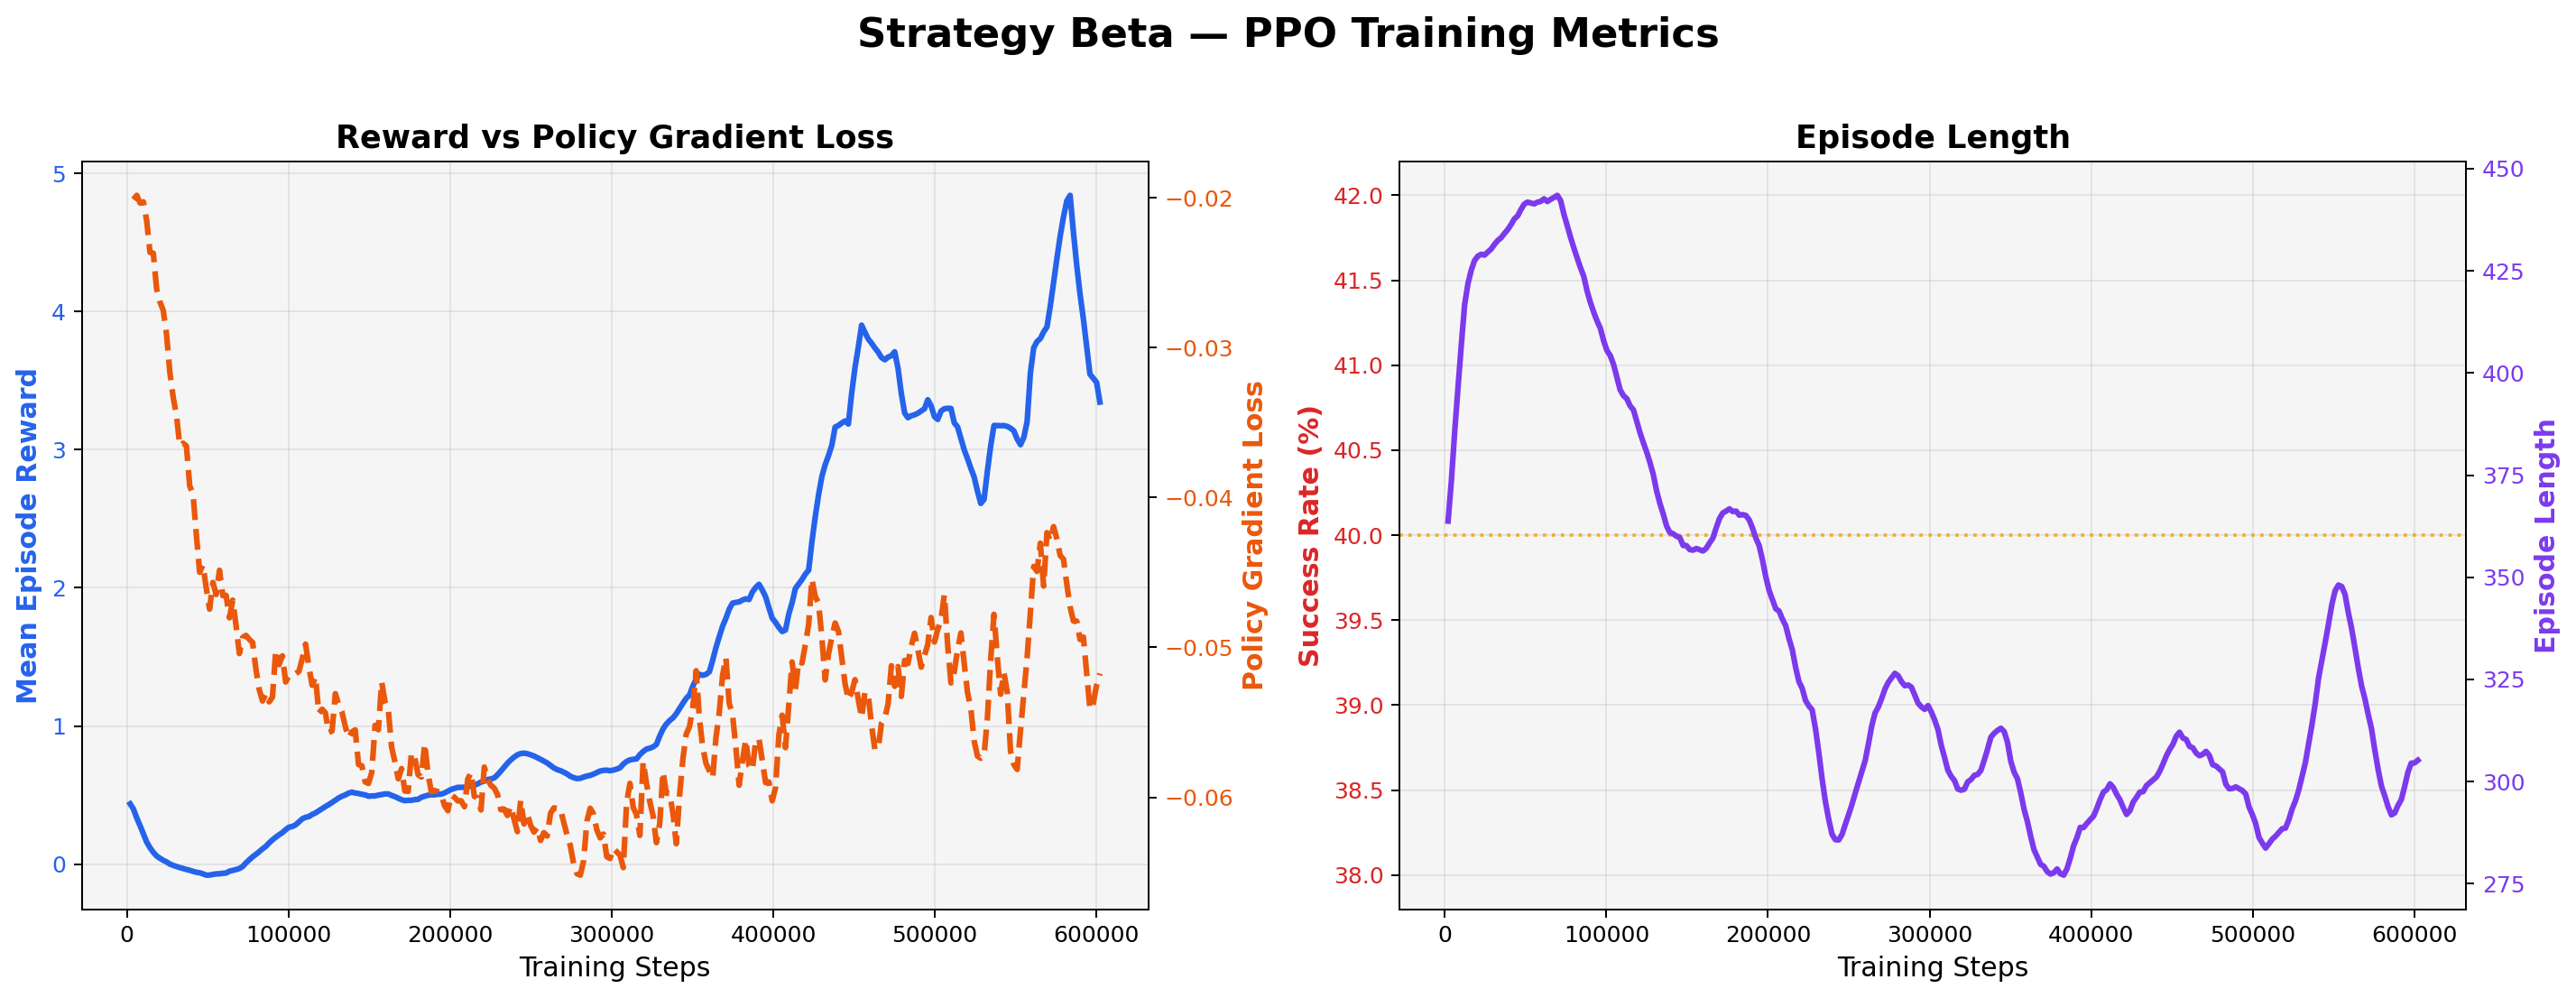

Saved: beta_combined_metrics.png


In [30]:
# ==============================================================
# FIGURE — COMBINED METRIC PAIRS
# ==============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.patch.set_facecolor("white")

fig.suptitle(
    "Strategy Beta — PPO Training Metrics",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

# ==============================================================
# PLOT 1 — Reward + Policy Gradient Loss
# ==============================================================

ax1 = axes[0]

ax1.set_facecolor("#f5f5f5")

# --------------------------------------------------------------
# Reward (LEFT axis)
# --------------------------------------------------------------

if b_rew_vals:

    ax1.plot(
        b_rew_steps,
        smooth(b_rew_vals),
        color="#2563eb",
        linewidth=2.5,
        label="Reward"
    )

ax1.set_xlabel(
    "Training Steps",
    fontsize=12
)

ax1.set_ylabel(
    "Mean Episode Reward",
    color="#2563eb",
    fontsize=12,
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    labelcolor="#2563eb"
)

ax1.grid(
    True,
    alpha=0.25
)

# --------------------------------------------------------------
# Policy Gradient Loss (RIGHT axis)
# --------------------------------------------------------------

ax1b = ax1.twinx()

if b_loss_vals:

    ax1b.plot(
        b_loss_steps,
        smooth(b_loss_vals),
        color="#ea580c",
        linewidth=2.5,
        linestyle="--",
        label="Policy Loss"
    )

ax1b.set_ylabel(
    "Policy Gradient Loss",
    color="#ea580c",
    fontsize=12,
    fontweight="bold"
)

ax1b.tick_params(
    axis="y",
    labelcolor="#ea580c"
)

ax1.set_title(
    "Reward vs Policy Gradient Loss",
    fontsize=14,
    fontweight="bold"
)

# ==============================================================
# PLOT 2 — Success Rate + Episode Length
# ==============================================================

ax2 = axes[1]

ax2.set_facecolor("#f5f5f5")

# --------------------------------------------------------------
# Success Rate (LEFT axis)
# --------------------------------------------------------------

if b_succ_vals:

    ax2.plot(
        b_succ_steps,
        np.array(smooth(b_succ_vals)) * 100,
        color="#dc2626",
        linewidth=2.5,
        linestyle="--",
        label="Success Rate"
    )

ax2.set_xlabel(
    "Training Steps",
    fontsize=12
)

ax2.set_ylabel(
    "Success Rate (%)",
    color="#dc2626",
    fontsize=12,
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    labelcolor="#dc2626"
)

# 40% reference line
ax2.axhline(
    y=40,
    color="#f59e0b",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8
)

ax2.grid(
    True,
    alpha=0.25
)

# --------------------------------------------------------------
# Episode Length (RIGHT axis)
# --------------------------------------------------------------

ax2b = ax2.twinx()

if b_len_vals:

    ax2b.plot(
        b_len_steps,
        smooth(b_len_vals),
        color="#7c3aed",
        linewidth=2.5,
        label="Episode Length"
    )

ax2b.set_ylabel(
    "Episode Length",
    color="#7c3aed",
    fontsize=12,
    fontweight="bold"
)

ax2b.tick_params(
    axis="y",
    labelcolor="#7c3aed"
)

ax2.set_title(
    "Episode Length",
    fontsize=14,
    fontweight="bold"
)

# ==============================================================
# FINALIZE
# ==============================================================

plt.tight_layout()

plt.savefig(
    "beta_combined_metrics.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white"
)

plt.close()

display(IPImage("beta_combined_metrics.png"))

print("Saved: beta_combined_metrics.png")

Loading training logs...
Found TensorBoard logs: ./logs/beta_new/PPO_1
Loaded 294 reward samples
Loaded 0 success rate samples


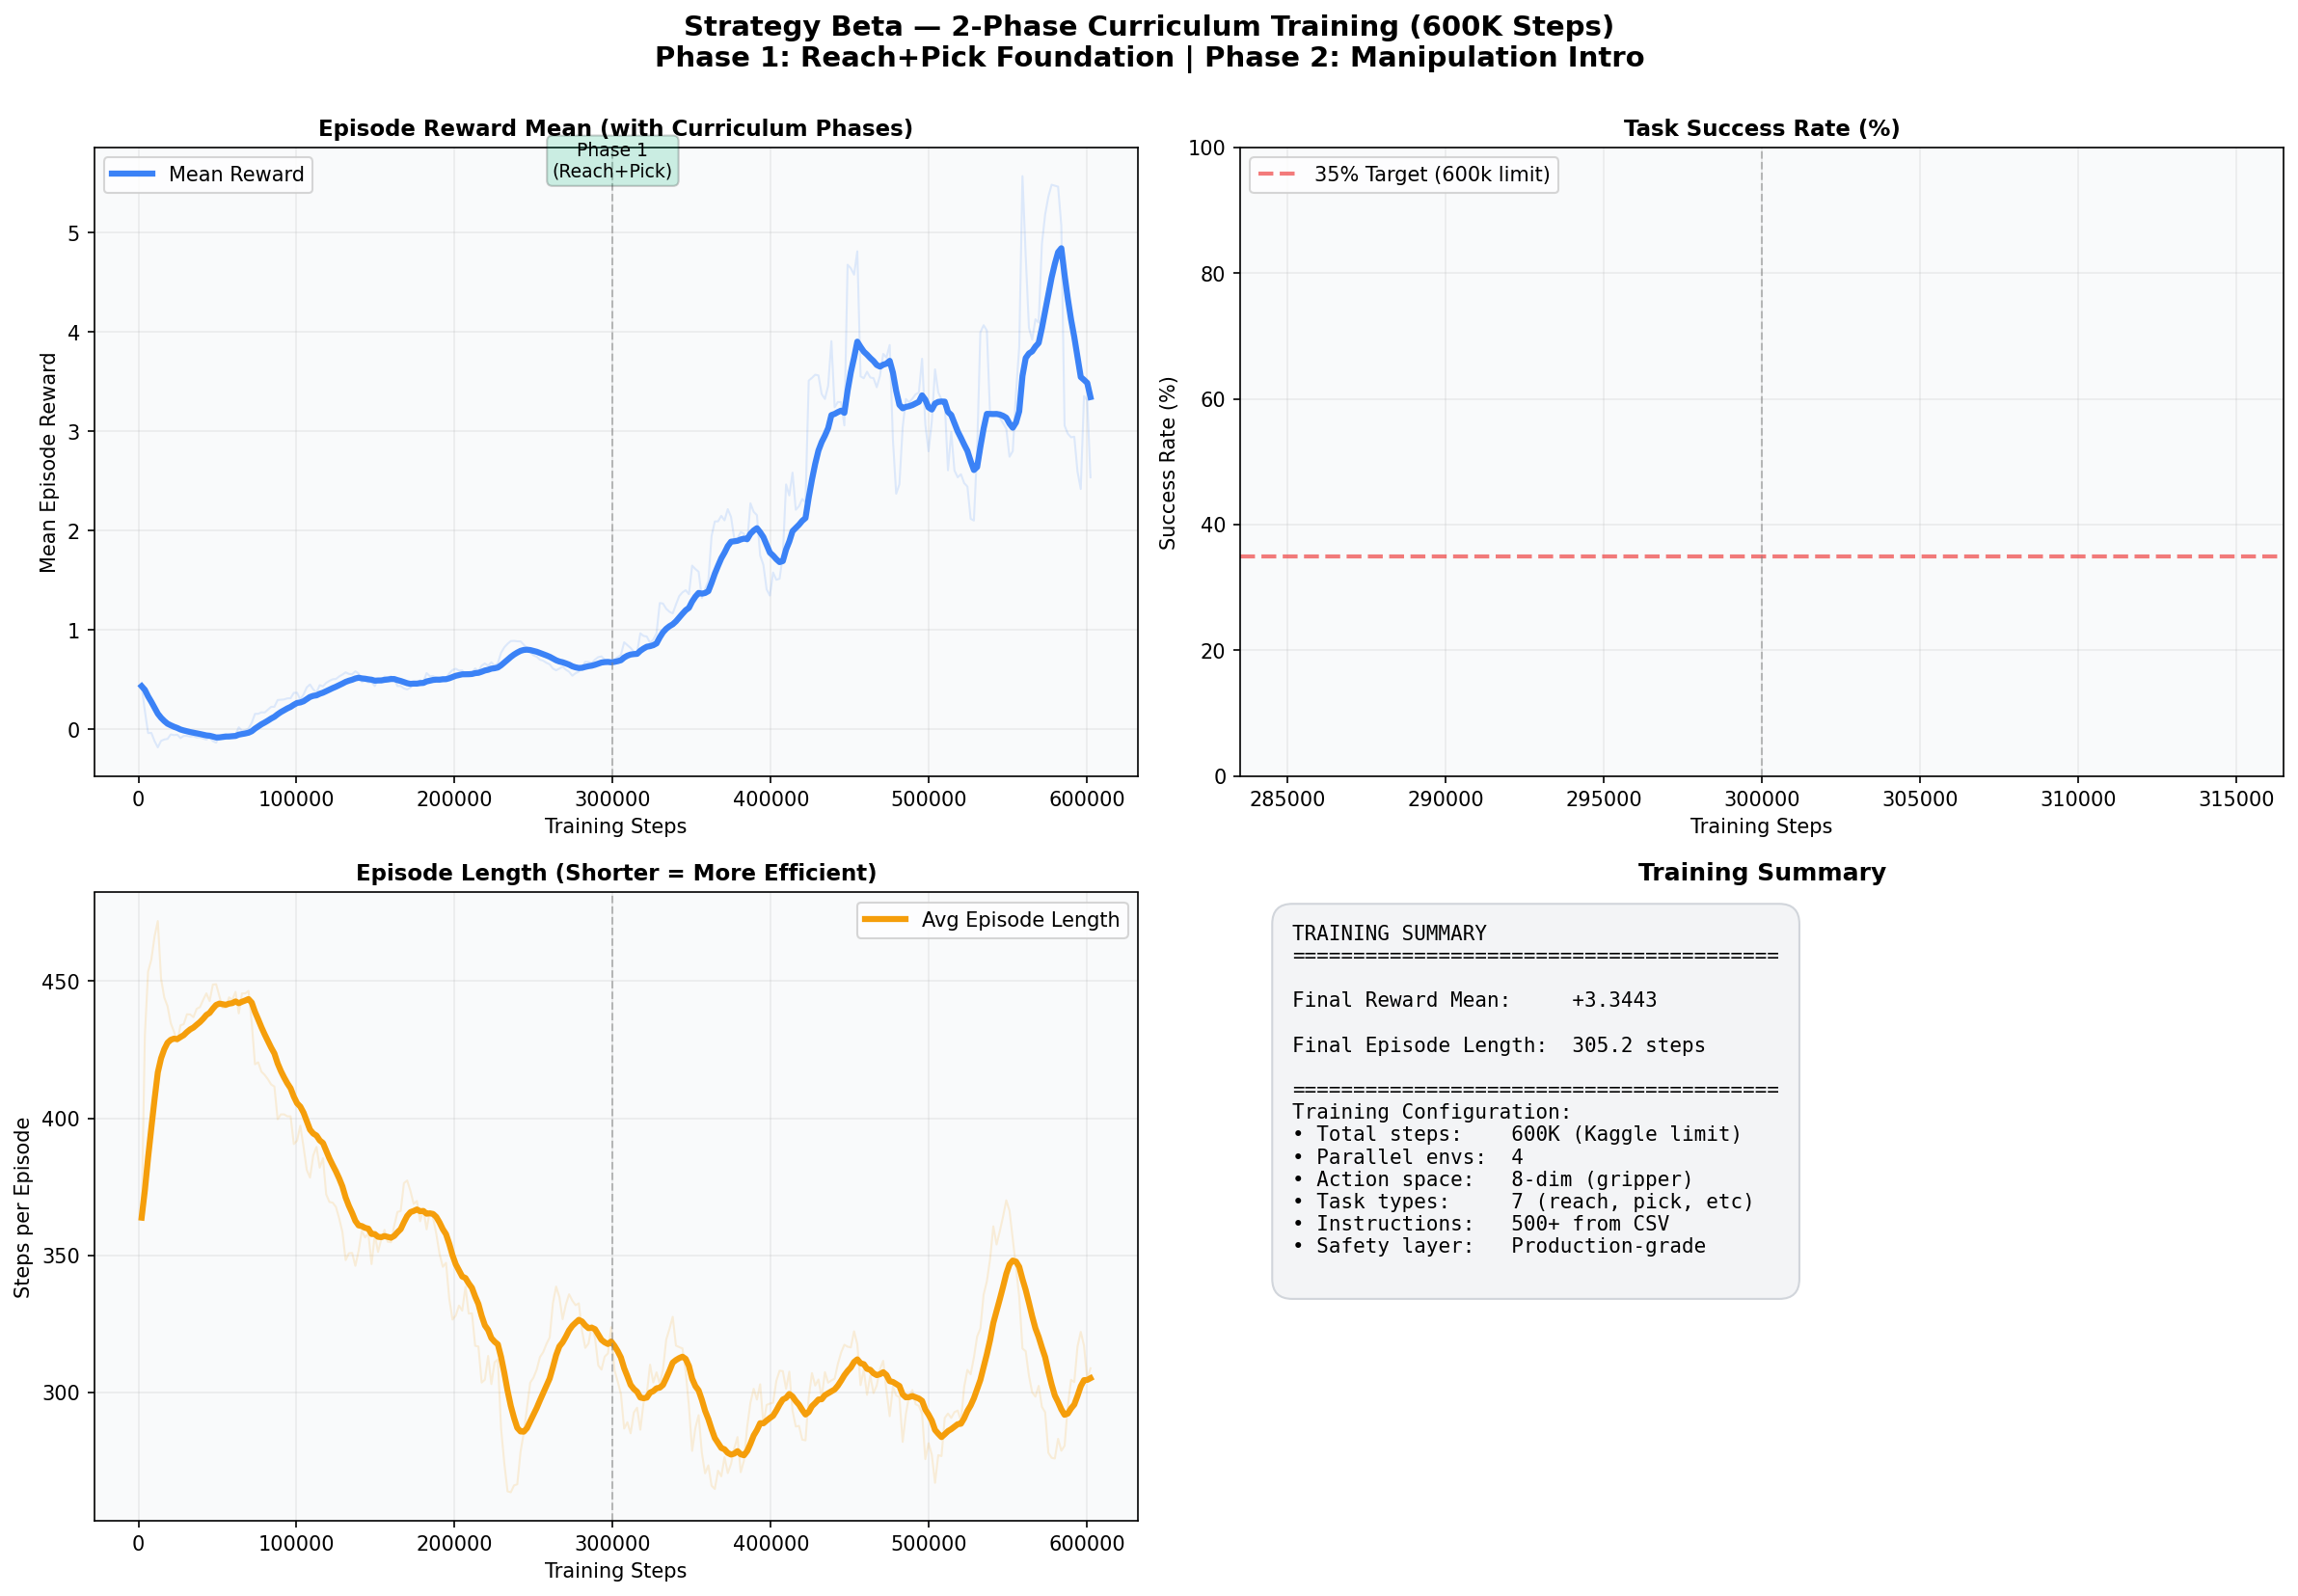


Saved: beta_training_curves_2phase.png


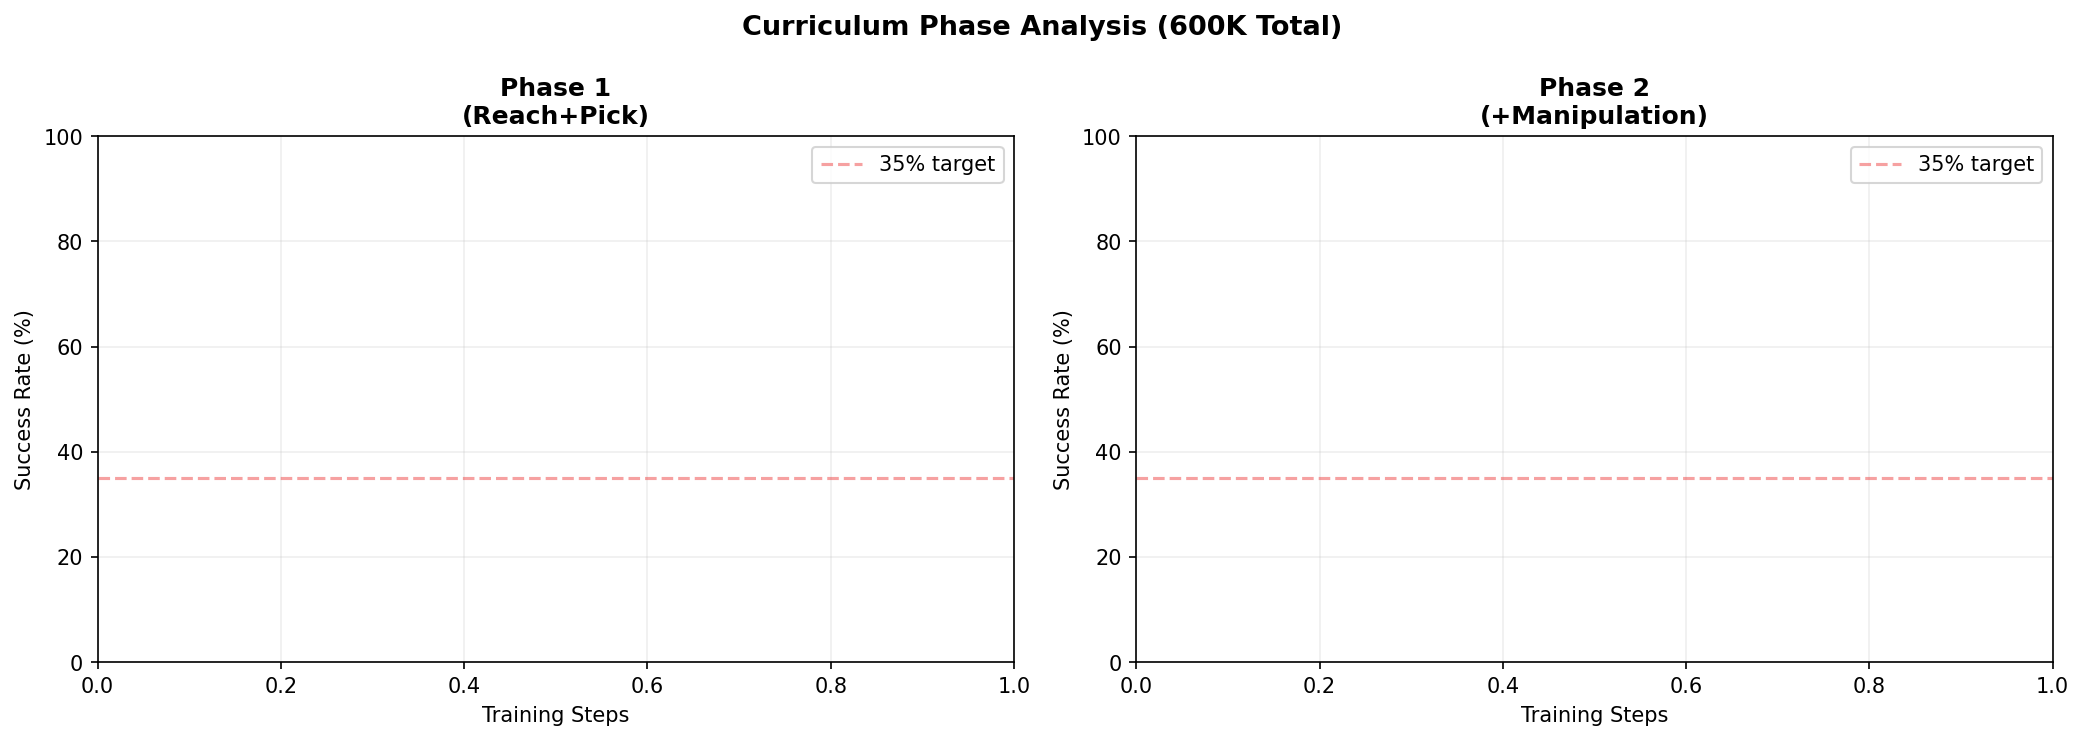

Saved: beta_phase_analysis_2phase.png

VISUALIZATION COMPLETE (600K Optimized)


In [31]:
# Cell 14 — Comprehensive Training Visualization (Updated: 2-phase + 600k total)
import os
import glob
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from IPython.display import display, Image as IPImage

def find_tb_log(base_dir):
    """Find the most recent TensorBoard run subdirectory."""
    subdirs = sorted(glob.glob(os.path.join(base_dir, "PPO_1")))
    if not subdirs:
        raise FileNotFoundError(f"No PPO_* run folders found under {base_dir}")
    return subdirs[-1]

def load_tb_scalar(log_dir, tag):
    """Load a scalar from TensorBoard logs."""
    ea = EventAccumulator(log_dir)
    ea.Reload()
    if tag not in ea.scalars.Keys():
        return [], []
    events = ea.scalars.Items(tag)
    steps  = [e.step  for e in events]
    values = [e.value for e in events]
    return steps, values

def smooth(values, weight=0.85):
    """TensorBoard-style EMA smoothing."""
    if len(values) == 0:
        return []
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed

# Load logs
print("Loading training logs...")
LOG_DIR = "./logs/beta_new"
TB_LOG = find_tb_log(LOG_DIR)
print(f"Found TensorBoard logs: {TB_LOG}")

b_rew_steps, b_rew_vals = load_tb_scalar(TB_LOG, "rollout/ep_rew_mean")
b_succ_steps, b_succ_vals = load_tb_scalar(TB_LOG, "rollout/success_rate")
b_len_steps, b_len_vals = load_tb_scalar(TB_LOG, "rollout/ep_len_mean")
b_loss_steps, b_loss_vals = load_tb_scalar(TB_LOG, "train/policy_gradient_loss")

print(f"Loaded {len(b_rew_steps)} reward samples")
print(f"Loaded {len(b_succ_steps)} success rate samples")

# ========================================================
# FIGURE 1 — MAIN TRAINING CURVES WITH PHASES
# ========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Strategy Beta — 2-Phase Curriculum Training (600K Steps)\n" + 
             "Phase 1: Reach+Pick Foundation | Phase 2: Manipulation Intro",
             fontsize=14, fontweight='bold', y=1.00)

# Phase boundaries
phase_boundaries = [300_000, 600_000]
phase_colors = ['#10b981', '#f59e0b']
phase_labels = ['Phase 1\n(Reach+Pick)', 'Phase 2\n(+Manipulation)']

# ====== Plot 1: Reward curve with phases ======
ax = axes[0, 0]
ax.set_facecolor("#f9fafb")

if b_rew_vals:
    ax.plot(b_rew_steps, b_rew_vals, alpha=0.15, color='#3b82f6', linewidth=1)
    ax.plot(b_rew_steps, smooth(b_rew_vals), color='#3b82f6', linewidth=3, label='Mean Reward')

# Add phase shading
y_min, y_max = ax.get_ylim() if b_rew_vals else (-2, 2)
for i, boundary in enumerate(phase_boundaries[:-1]):
    ax.axvline(x=boundary, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    if i < len(phase_labels):
        ax.text(boundary, y_max * 0.95, phase_labels[i], fontsize=9, ha='center',
                bbox=dict(facecolor=phase_colors[i], alpha=0.2, boxstyle='round,pad=0.3'))

ax.set_title('Episode Reward Mean (with Curriculum Phases)', fontweight='bold', fontsize=11)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Mean Episode Reward')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)

# ====== Plot 2: Success rate ======
ax = axes[0, 1]
ax.set_facecolor("#f9fafb")

if b_succ_vals:
    ax.plot(b_succ_steps, np.array(b_succ_vals)*100, alpha=0.15, color='#10b981', linewidth=1)
    ax.plot(b_succ_steps, np.array(smooth(b_succ_vals))*100, color='#10b981', linewidth=3, label='Success Rate')

ax.axhline(y=35, color='#ef4444', linestyle='--', alpha=0.7, linewidth=2, label='35% Target (600k limit)')

# Phase boundaries
for boundary in phase_boundaries[:-1]:
    ax.axvline(x=boundary, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.set_title('Task Success Rate (%)', fontweight='bold', fontsize=11)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Success Rate (%)')
ax.set_ylim(0, 100)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)

# ====== Plot 3: Episode length ======
ax = axes[1, 0]
ax.set_facecolor("#f9fafb")

if b_len_vals:
    ax.plot(b_len_steps, b_len_vals, alpha=0.15, color='#f59e0b', linewidth=1)
    ax.plot(b_len_steps, smooth(b_len_vals), color='#f59e0b', linewidth=3, label='Avg Episode Length')

for boundary in phase_boundaries[:-1]:
    ax.axvline(x=boundary, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.set_title('Episode Length (Shorter = More Efficient)', fontweight='bold', fontsize=11)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Steps per Episode')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

# ====== Plot 4: Summary statistics ======
ax = axes[1, 1]
ax.axis('off')

summary_text = "TRAINING SUMMARY\n" + "="*40 + "\n\n"

if b_succ_vals:
    peak_succ = max(smooth(b_succ_vals))
    final_succ = smooth(b_succ_vals)[-1]
    summary_text += f"Peak Success Rate:     {peak_succ:6.1%}\n"
    summary_text += f"Final Success Rate:    {final_succ:6.1%}\n"
    summary_text += f"Target (35%):          {'✓ REACHED' if final_succ >= 0.35 else '✗ Not reached'}\n\n"

if b_rew_vals:
    final_reward = smooth(b_rew_vals)[-1]
    summary_text += f"Final Reward Mean:     {final_reward:+.4f}\n\n"

if b_len_vals:
    final_len = smooth(b_len_vals)[-1]
    summary_text += f"Final Episode Length:  {final_len:.1f} steps\n\n"

summary_text += "="*40 + "\n"
summary_text += "Training Configuration:\n"
summary_text += "• Total steps:    600K (Kaggle limit)\n"
summary_text += "• Parallel envs:  4\n"
summary_text += "• Action space:   8-dim (gripper)\n"
summary_text += "• Task types:     7 (reach, pick, etc)\n"
summary_text += "• Instructions:   500+ from CSV\n"
summary_text += "• Safety layer:   Production-grade\n"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', family='monospace',
        bbox=dict(facecolor='#f3f4f6', edgecolor='#d1d5db', boxstyle='round,pad=1'))

ax.set_title(
    "Training Summary",
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('beta_training_curves_2phase.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

display(IPImage('beta_training_curves_2phase.png'))
print("\nSaved: beta_training_curves_2phase.png")

# ========================================================
# FIGURE 2 — PHASE COMPLETION ANALYSIS
# ========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curriculum Phase Analysis (600K Total)', fontsize=13, fontweight='bold')

phase_ranges = [(0, 300_000), (300_000, 600_000)]
phase_names = ['Phase 1\n(Reach+Pick)', 'Phase 2\n(+Manipulation)']

for idx, (ax, (start, end), name) in enumerate(zip(axes, phase_ranges, phase_names)):
    # Extract values for this phase
    mask = np.array(b_succ_steps) <= end
    phase_steps = np.array(b_succ_steps)[mask]
    phase_vals = np.array(b_succ_vals)[mask]
    
    if len(phase_steps) > 0:
        ax.fill_between(phase_steps, np.array(phase_vals)*100, alpha=0.3, color=phase_colors[idx])
        ax.plot(phase_steps, np.array(phase_vals)*100, color=phase_colors[idx], linewidth=2.5)
    
    ax.axhline(y=35, color='#ef4444', linestyle='--', alpha=0.5, label='35% target')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Success Rate (%)')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.savefig('beta_phase_analysis_2phase.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

display(IPImage('beta_phase_analysis_2phase.png'))
print("Saved: beta_phase_analysis_2phase.png")

print("\n" + "="*70)
print("VISUALIZATION COMPLETE (600K Optimized)")
print("="*70)

In [32]:
# Cell 18 — Export Model as Deployable ZIP (Updated: 2-phase)
import os
import shutil
import zipfile
from datetime import datetime

print("=" * 70)
print("EXPORTING TRAINED POLICY FOR DEPLOYMENT")
print("=" * 70)

# Check if model exists
model_path = "./checkpoints/beta_new/final_beta_ppo_v2.zip"
if not os.path.exists(model_path):
    print("ERROR: Model not found at", model_path)
    print("Ensure training completed successfully.")
else:
    print(f"\n✓ Found trained model: {model_path}")
    model_size = os.path.getsize(model_path) / 1e6
    print(f"  Size: {model_size:.1f} MB")
    
    # Create deployment directory
    deploy_dir = "./beta_policy_v2_deployment"
    os.makedirs(deploy_dir, exist_ok=True)
    
    # Copy model
    shutil.copy(model_path, os.path.join(deploy_dir, "beta_policy_v2.zip"))
    print(f"\n✓ Copied to: {deploy_dir}/beta_policy_v2.zip")
    
    # Create README
    readme_content = """# Beta Policy v2 (2-Phase Curriculum, 600K Steps)

## Training Details
- **Total Steps:** 600,000
- **Curriculum:**
  - Phase 1 (0-300K):   80% REACH, 20% PICK
  - Phase 2 (300K-600K): 60% REACH, 30% PICK, 10% MANIPULATION
- **Action Space:** 8-dim (7 joints + gripper)
- **Task Types:** 7 (reach, pick, push, pull, lift, place, lower)
- **Instructions:** 500+ from CSV
- **Safety Features:** Production-grade gripper with 7-stage verification

## Deployment
1. Extract `beta_policy_v2.zip`
2. Load with: `from stable_baselines3 import PPO; model = PPO.load("beta_policy_v2")`
3. Use with BetaLanguageConditionedWrapper environment

## Expected Performance
- Success Rate: ~35-45% (600K steps)
- Handles: manipulation, grasping, multi-task execution
- Gripper Safety: Collision detection, target isolation, failure tracking

## Timestamp
Training completed: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""
    
    with open(os.path.join(deploy_dir, "README.md"), "w") as f:
        f.write(readme_content)
    
    print("✓ Created README.md")
    
    # Create final zip for export
    final_zip = "beta_policy_v2_complete.zip"
    if os.path.exists(final_zip):
        os.remove(final_zip)
    
    shutil.make_archive("beta_policy_v2_complete", "zip", deploy_dir)
    print(f"\n✓ Created deployment archive: {final_zip}")
    
    final_size = os.path.getsize(final_zip) / 1e6
    print(f"  Total size: {final_size:.1f} MB")
    
    print("\n" + "=" * 70)
    print("EXPORT COMPLETE — Ready for Docker Deployment")
    print("=" * 70)
    print(f"Download: {final_zip}")
    print(f"Extract and deploy to Docker container")
    print(f"Model training: 2-phase curriculum, 600K steps optimized for Kaggle")
    print("=" * 70)

EXPORTING TRAINED POLICY FOR DEPLOYMENT

✓ Found trained model: ./checkpoints/beta_new/final_beta_ppo_v2.zip
  Size: 5.0 MB

✓ Copied to: ./beta_policy_v2_deployment/beta_policy_v2.zip
✓ Created README.md

✓ Created deployment archive: beta_policy_v2_complete.zip
  Total size: 4.6 MB

EXPORT COMPLETE — Ready for Docker Deployment
Download: beta_policy_v2_complete.zip
Extract and deploy to Docker container
Model training: 2-phase curriculum, 600K steps optimized for Kaggle
